# KuaiRec — feature & label analysis before training a ranking model

Findings + the numbers this run produced: [`kuairec_eda_findings.md`](kuairec_eda_findings.md).

## What to decide from this notebook
1. Is `watch_ratio` a sane regression label (scale, outliers, missing)?
2. Which dense fields are skewed → `log1p` vs leave raw vs quantile CDF?
3. Which categoricals carry signal (label lift) vs noise / rarity — and which are duplicates of each other?
4. Are hand-picked wide crosses worth keeping (support + interaction lift vs main effects)?
5. Does the train/val/test split hold up (no missing-rate or mean drift)?


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path("..").resolve() if Path.cwd().name == "data" else Path.cwd()
RAW = ROOT / "data" / "raw" / "kuairec"
EXTRACT = ROOT / "data" / "extract" / "kuairec"

# IDE kernel cwd is this file's own directory (data/); the `data` *package*
# isn't importable from inside itself without repo root on sys.path. Do it
# once, here, so every later `from data....` cell works regardless of which
# cells get (re-)run afterwards.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("ROOT", ROOT)
assert (RAW / "small_matrix.csv").exists(), "Download KuaiRec raw data first (see data/README.md)"

ROOT /Users/giunglee/Projects/short-video-feed-ranker


## 0. Dataset overview

Goals:
- How big / dense is this dataset (users, videos, interactions)?
- What auxiliary signals exist outside the interaction table itself (social
  graph, content tags) that a real feed ranker would also have access to?

In [2]:
matrix = pd.read_csv(RAW / "small_matrix.csv")
item_categories = pd.read_csv(RAW / "item_categories.csv")
item_categories["feat"] = item_categories["feat"].map(eval)
social_network = pd.read_csv(RAW / "social_network.csv")
social_network["friend_list"] = social_network["friend_list"].map(eval)

n_users = matrix["user_id"].nunique()
n_videos = matrix["video_id"].nunique()
n_rows = len(matrix)
print(f"users={n_users:,}  videos={n_videos:,}  interactions={n_rows:,}")
print(f"interaction density={n_rows / (n_users * n_videos):.2%} "
      f"(small_matrix is a dense fully-observed slice, not a random sample)")

users=1,411  videos=3,327  interactions=4,676,570
interaction density=99.62% (small_matrix is a dense fully-observed slice, not a random sample)


count    10728.000000
mean         1.183166
std          0.436205
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
Name: feat, dtype: float64


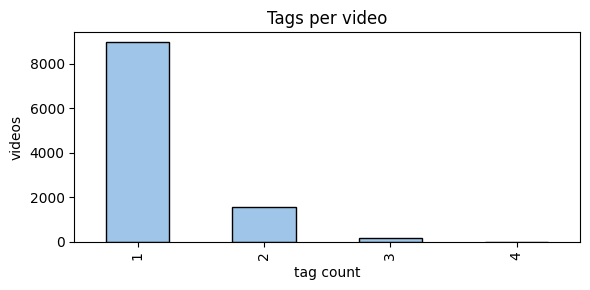

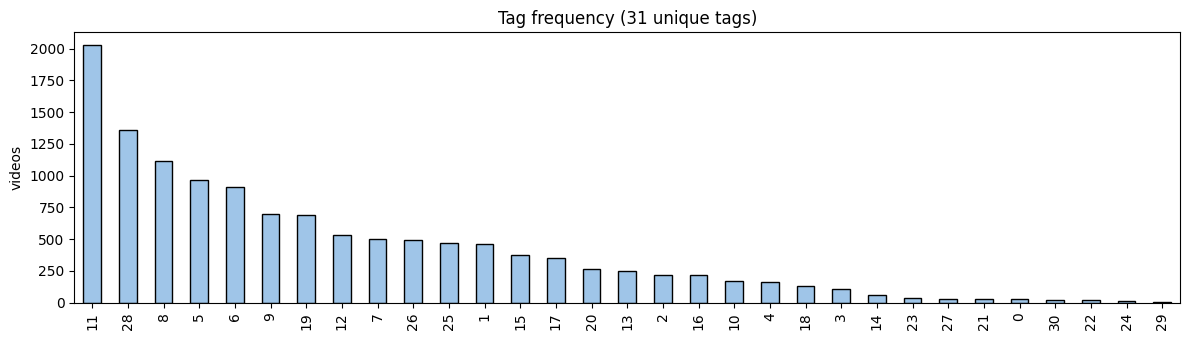

In [3]:
num_tags = item_categories["feat"].map(len)
print(num_tags.describe())

fig, ax = plt.subplots(figsize=(6, 3))
num_tags.value_counts().sort_index().plot(kind="bar", ax=ax, color="#9fc5e8", edgecolor="k")
ax.set_title("Tags per video")
ax.set_xlabel("tag count")
ax.set_ylabel("videos")
plt.tight_layout()
plt.show()

tag_counts: dict[int, int] = {}
for tags in item_categories["feat"]:
    for t in tags:
        tag_counts[t] = tag_counts.get(t, 0) + 1
tag_series = pd.Series(tag_counts).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 3.5))
tag_series.plot(kind="bar", ax=ax, color="#9fc5e8", edgecolor="k")
ax.set_title(f"Tag frequency ({len(tag_series)} unique tags)")
ax.set_ylabel("videos")
plt.tight_layout()
plt.show()

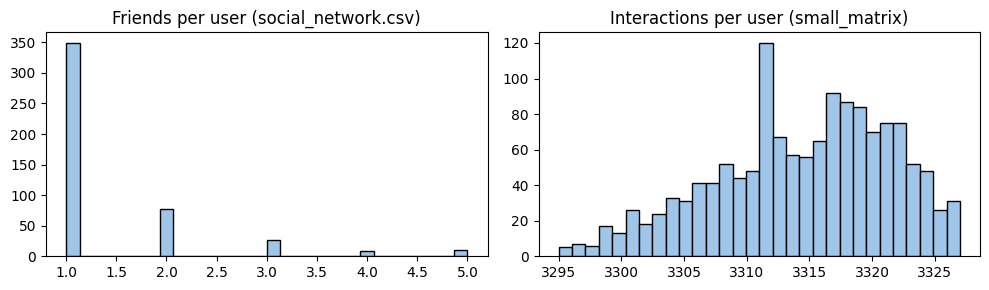

friends/user:
 count    472.000000
mean       1.419492
std        0.853295
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: friend_list, dtype: float64

interactions/user:
 count    1411.000000
mean     3314.365698
std         6.984852
min      3295.000000
25%      3309.000000
50%      3315.000000
75%      3320.000000
max      3327.000000
dtype: float64


In [4]:
friend_counts = social_network["friend_list"].map(len)
play_counts = matrix.groupby("user_id").size()

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(friend_counts, bins=30, color="#9fc5e8", edgecolor="k")
ax[0].set_title("Friends per user (social_network.csv)")
ax[1].hist(play_counts, bins=30, color="#9fc5e8", edgecolor="k")
ax[1].set_title("Interactions per user (small_matrix)")
plt.tight_layout()
plt.show()

print("friends/user:\n", friend_counts.describe())
print("\ninteractions/user:\n", play_counts.describe())

## 1. Label analysis — `watch_ratio`

Goals:
- Distribution / heavy tail / values ≫ 1?
- Predict-mean MAE baseline (what models must beat)
- Temporal drift (train vs later days) if a time split is used

Dropped 181992 rows with missing timestamp (3.89%)
count    4.494578e+06
mean     9.113757e-01
std      1.356487e+00
min      0.000000e+00
50%      7.745146e-01
90%      1.562793e+00
95%      1.956654e+00
99%      3.584618e+00
max      5.715214e+02
Name: watch_ratio, dtype: float64
frac > 1: 0.3274031510855969
frac null: 0.0


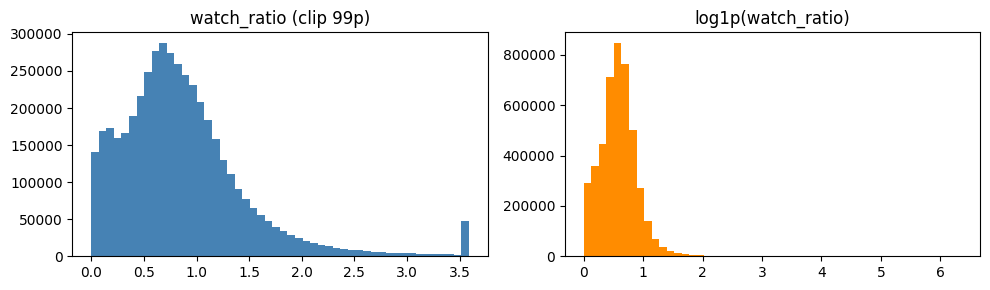

global mean=0.9114, MAE(predict-mean)=0.4871


In [5]:
# date is stored as a numeric YYYYMMDD (e.g. 20200705.0), not a date string —
# pd.to_datetime() on a raw numeric column reads it as ns-since-epoch and
# silently collapses every row to 1970-01-01. Force the real format instead.
n_before = len(matrix)
matrix = matrix.dropna(subset=["date"])
n_after = len(matrix)
print(f"Dropped {n_before - n_after} rows with missing timestamp ({(n_before-n_after)/n_before:.2%})")

matrix["date"] = pd.to_datetime(
    matrix["date"].astype("int64").astype(str), format="%Y%m%d"
)

y = pd.to_numeric(matrix["watch_ratio"], errors="coerce")
print(y.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))
print("frac > 1:", float((y > 1).mean()))
print("frac null:", float(y.isna().mean()))

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(y.clip(upper=y.quantile(0.99)), bins=50, color="steelblue")
ax[0].set_title("watch_ratio (clip 99p)")
ax[1].hist(np.log1p(y.clip(lower=0)), bins=50, color="darkorange")
ax[1].set_title("log1p(watch_ratio)")
plt.tight_layout()
plt.show()

# Naive constant baseline on full small matrix (not the temporal split — illustrative)
mu = float(y.mean())
mae = float(np.abs(y - mu).mean())
print(f"global mean={mu:.4f}, MAE(predict-mean)={mae:.4f}")

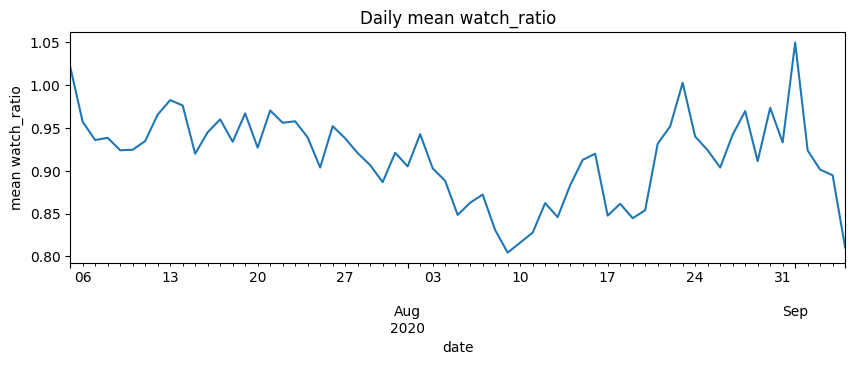

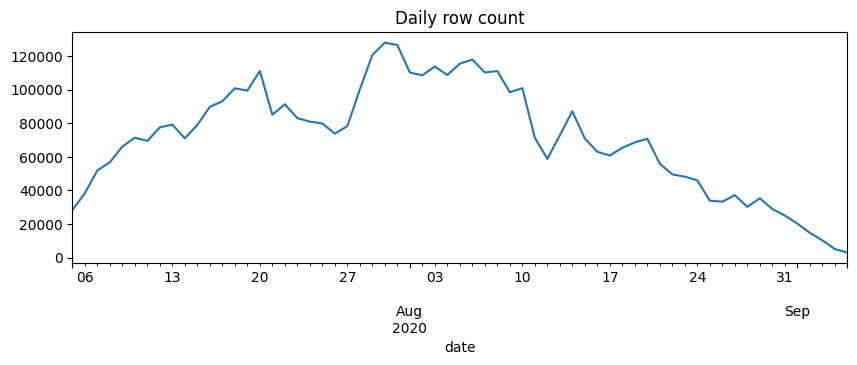

In [6]:
# Temporal drift of label (aligns with preprocessor time split idea)
daily = matrix.assign(watch_ratio=y).groupby("date")["watch_ratio"].agg(["mean", "count"])
daily["mean"].plot(figsize=(10, 3), title="Daily mean watch_ratio")
plt.ylabel("mean watch_ratio")
plt.show()
daily["count"].plot(figsize=(10, 3), title="Daily row count")
plt.show()

## 2. Dense features — skew and transform choice

Goals:
- Which dense fields are heavy-tailed enough that raw values would dominate a linear layer?
- `log1p` vs raw, side by side.

In [7]:
users = pd.read_csv(RAW / "user_features.csv")
user_raw = pd.read_csv(RAW / "user_features_raw.csv")
items = pd.read_csv(RAW / "item_daily_features.csv")
items = items.rename(columns={
    "show_cnt": "video_daily_show_cnt",
    "show_user_num": "video_daily_show_user_num",
    "play_cnt": "video_daily_play_cnt",
    "play_user_num": "video_daily_play_user_num",
    "play_duration": "video_daily_play_duration",
    "complete_play_cnt": "video_daily_complete_play_cnt",
    "complete_play_user_num": "video_daily_complete_play_user_num",
    "valid_play_cnt": "video_daily_valid_play_cnt",
    "valid_play_user_num": "video_daily_valid_play_user_num",
    "long_time_play_cnt": "video_daily_long_time_play_cnt",
    "long_time_play_user_num": "video_daily_long_time_play_user_num",
    "short_time_play_cnt": "video_daily_short_time_play_cnt",
    "short_time_play_user_num": "video_daily_short_time_play_user_num",
    "play_progress": "video_daily_play_progress",
    "comment_stay_duration": "video_daily_comment_stay_duration",
    "like_cnt": "video_daily_like_cnt",
    "like_user_num": "video_daily_like_user_num",
    "click_like_cnt": "video_daily_click_like_cnt",
    "double_click_cnt": "video_daily_double_click_cnt",
    "cancel_like_cnt": "video_daily_cancel_like_cnt",
    "cancel_like_user_num": "video_daily_cancel_like_user_num",
    "comment_cnt": "video_daily_comment_cnt",
    "comment_user_num": "video_daily_comment_user_num",
    "direct_comment_cnt": "video_daily_direct_comment_cnt",
    "reply_comment_cnt": "video_daily_reply_comment_cnt",
    "delete_comment_cnt": "video_daily_delete_comment_cnt",
    "delete_comment_user_num": "video_daily_delete_comment_user_num",
    "comment_like_cnt": "video_daily_comment_like_cnt",
    "comment_like_user_num": "video_daily_comment_like_user_num",
    "follow_cnt": "video_daily_follow_cnt",
    "follow_user_num": "video_daily_follow_user_num",
    "cancel_follow_cnt": "video_daily_cancel_follow_cnt",
    "cancel_follow_user_num": "video_daily_cancel_follow_user_num",
    "share_cnt": "video_daily_share_cnt",
    "share_user_num": "video_daily_share_user_num",
    "download_cnt": "video_daily_download_cnt",
    "download_user_num": "video_daily_download_user_num",
    "report_cnt": "video_daily_report_cnt",
    "report_user_num": "video_daily_report_user_num",
    "reduce_similar_cnt": "video_daily_reduce_similar_cnt",
    "reduce_similar_user_num": "video_daily_reduce_similar_user_num",
    "collect_cnt": "video_daily_collect_cnt",
    "collect_user_num": "video_daily_collect_user_num",
    "cancel_collect_cnt": "video_daily_cancel_collect_cnt",
    "cancel_collect_user_num": "video_daily_cancel_collect_user_num",
})

# users/user_raw share 9 column names (user_active_degree, follow/fans/
# friend_user_num[_range], register_days[_range]) — merging the full
# user_raw frame would silently suffix those to _x/_y. Keep only user_raw's
# exclusive columns (mirrors KuaiRecPreprocessor.users_raw subset).
user_raw = user_raw[[
    "user_id", "gender", "age_range", "is_live_author", "is_photo_author",
    "phone_brand", "phone_model", "mod_price",
    "fre_country", "fre_country_region", "fre_province", "fre_city",
    "fre_city_level", "fre_community_type",
    "platform", "os_version", "app_version", "app_download_channel", "isp",
]]

df = matrix.merge(users, on="user_id", how="left")
df = df.merge(user_raw, on="user_id", how="left")
items["date"] = pd.to_datetime(
    items["date"].astype("int64").astype(str), format="%Y%m%d"
)

df = df.merge(items, on=["video_id", "date"], how="left")

In [8]:
DENSE_CANDIDATES = [
    "video_duration",
    "follow_user_num",
    "fans_user_num",
    "friend_user_num",
    "register_days",
    "video_width",
    "video_height",
    "video_daily_show_cnt",
    "video_daily_show_user_num",
    "video_daily_play_cnt",
    "video_daily_play_user_num",
    "video_daily_complete_play_cnt",
    "video_daily_complete_play_user_num",
    "video_daily_valid_play_cnt",
    "video_daily_valid_play_user_num",
    "video_daily_long_time_play_cnt",
    "video_daily_long_time_play_user_num",
    "video_daily_short_time_play_cnt",
    "video_daily_short_time_play_user_num",
    "video_daily_comment_stay_duration",
    "video_daily_like_cnt",
    "video_daily_like_user_num",
    "video_daily_click_like_cnt",
    "video_daily_double_click_cnt",
    "video_daily_cancel_like_cnt",
    "video_daily_cancel_like_user_num",
    "video_daily_comment_cnt",
    "video_daily_comment_user_num",
    "video_daily_direct_comment_cnt",
    "video_daily_reply_comment_cnt",
    "video_daily_delete_comment_cnt",
    "video_daily_delete_comment_user_num",
    "video_daily_comment_like_cnt",
    "video_daily_comment_like_user_num",
    "video_daily_follow_cnt",
    "video_daily_follow_user_num",
    "video_daily_cancel_follow_cnt",
    "video_daily_cancel_follow_user_num",
    "video_daily_share_cnt",
    "video_daily_share_user_num",
    "video_daily_download_cnt",
    "video_daily_download_user_num",
    "video_daily_report_cnt",
    "video_daily_report_user_num",
    "video_daily_reduce_similar_cnt",
    "video_daily_reduce_similar_user_num",
    "video_daily_collect_cnt",
    "video_daily_collect_user_num",
    "video_daily_cancel_collect_cnt",
    "video_daily_cancel_collect_user_num"
]

rows = []
for col in DENSE_CANDIDATES:
    if col not in df.columns:
        continue
    s = pd.to_numeric(df[col], errors="coerce")
    rows.append({
        "col": col,
        "null_frac": float(s.isna().mean()),
        "min": float(s.min()),
        "p50": float(s.quantile(0.5)),
        "p99": float(s.quantile(0.99)),
        "max": float(s.max()),
        "skew": float(s.skew()),
    })
pd.DataFrame(rows).sort_values("skew", ascending=False)

,col,null_frac,min,p50,p99,max,skew
47,video_daily_cancel_collect_cnt,0.390786,0.0,1.0,1.010000e+02,2.056000e+03,33.771751
48,video_daily_cancel_collect_user_num,0.390786,0.0,1.0,9.800000e+01,1.971000e+03,33.455087
29,video_daily_delete_comment_cnt,0.000000,0.0,3.0,2.565000e+03,5.189800e+04,31.688034
45,video_daily_collect_cnt,0.390786,0.0,14.0,6.495000e+03,1.169710e+05,28.339858
46,video_daily_collect_user_num,0.390786,0.0,13.0,6.460000e+03,1.158590e+05,28.287850
41,video_daily_report_cnt,0.000000,0.0,0.0,1.100000e+01,1.980000e+02,24.288899
42,video_daily_report_user_num,0.000000,0.0,0.0,1.000000e+01,1.760000e+02,23.595198
40,video_daily_download_user_num,0.000000,0.0,42.0,8.922000e+03,1.338020e+05,21.851875
39,video_daily_download_cnt,0.000000,0.0,43.0,9.546000e+03,1.340990e+05,20.208372
38,video_daily_share_user_num,0.000000,0.0,42.0,2.393000e+04,2.791870e+05,17.197418


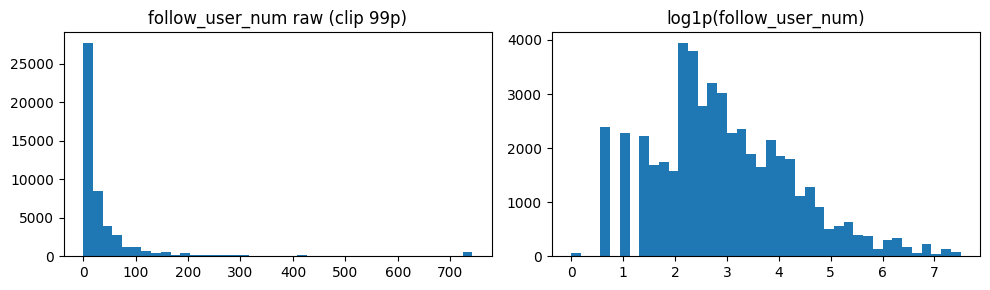

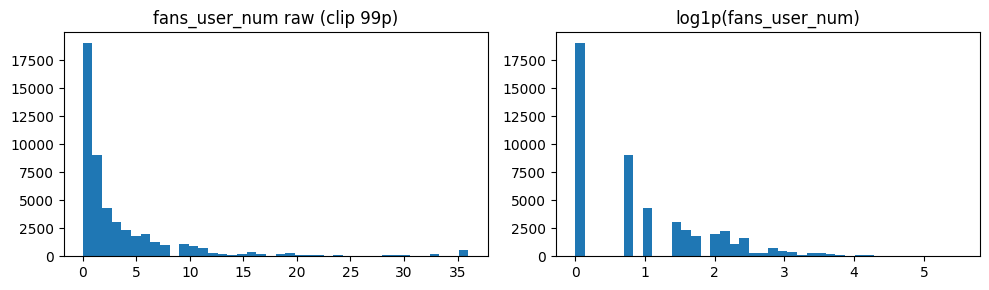

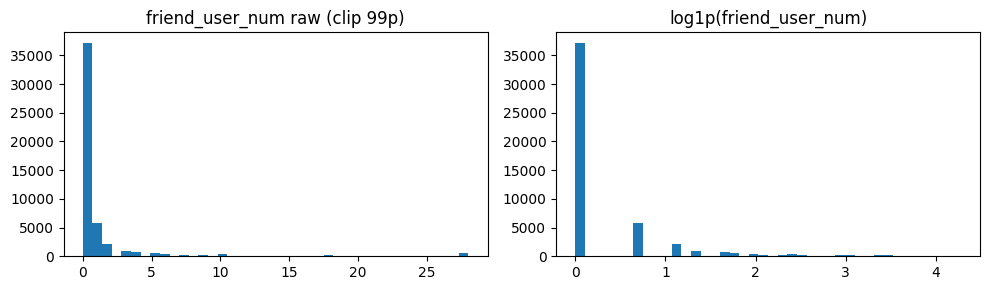

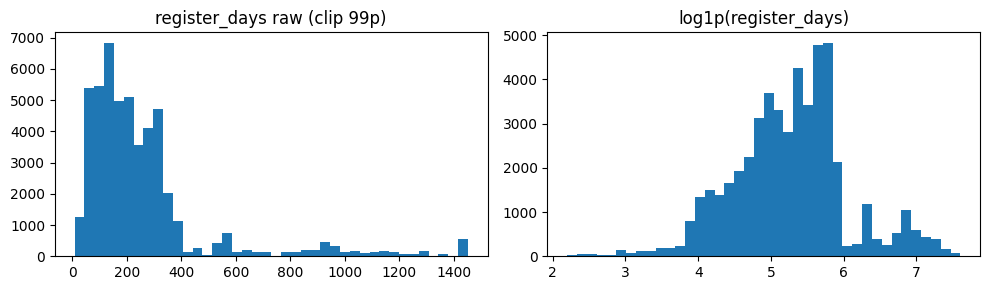

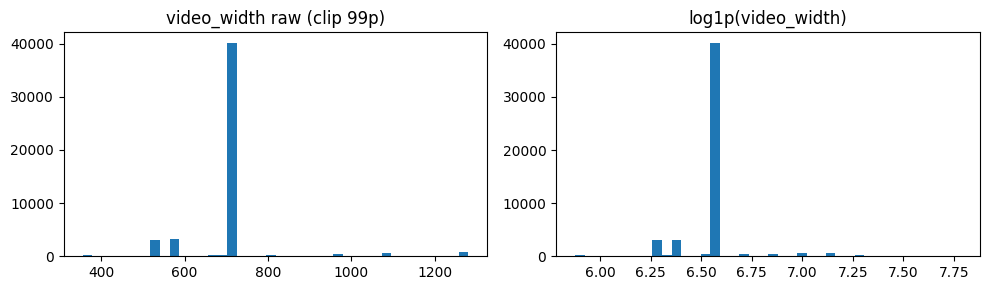

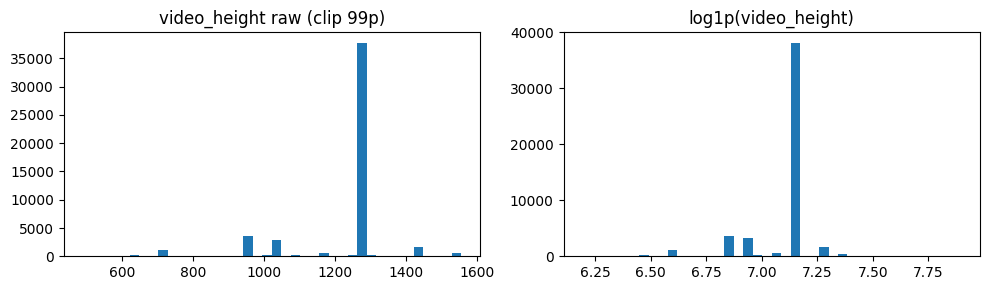

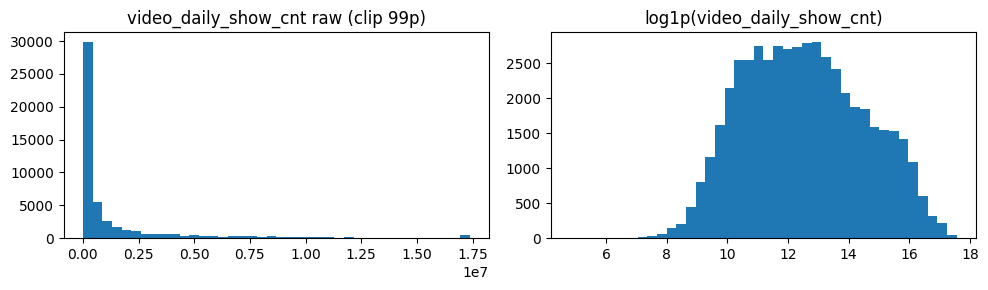

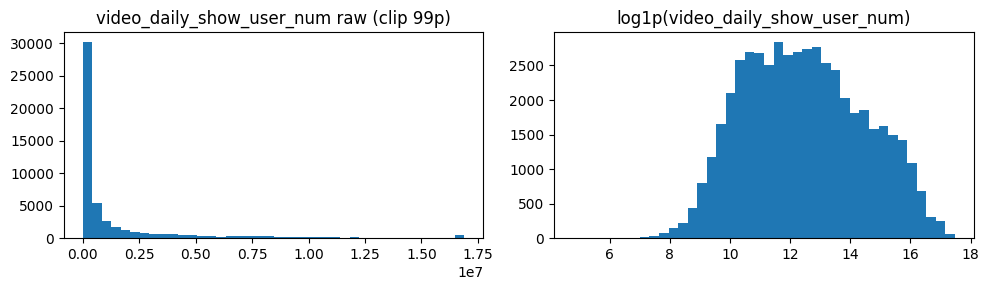

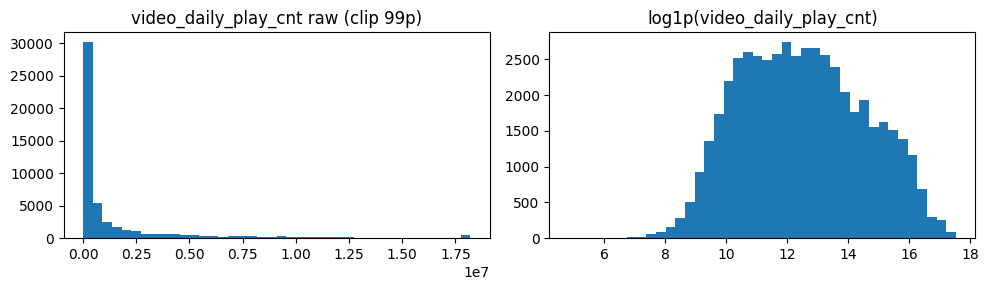

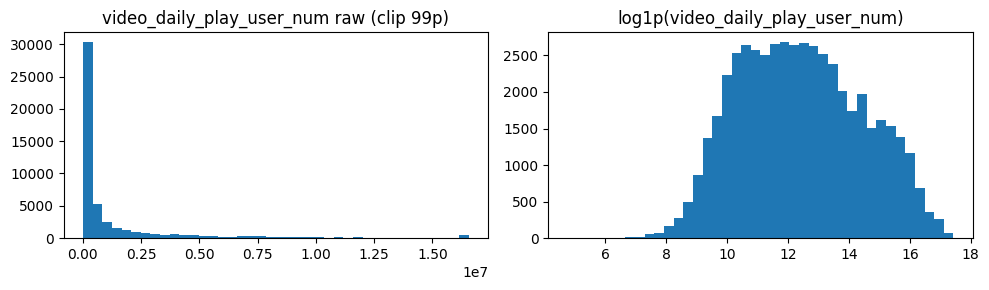

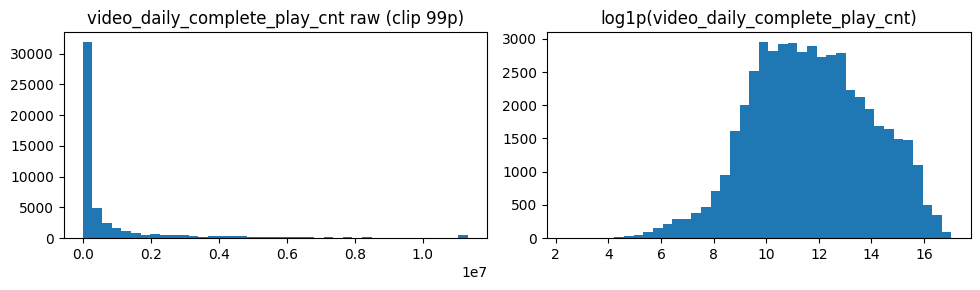

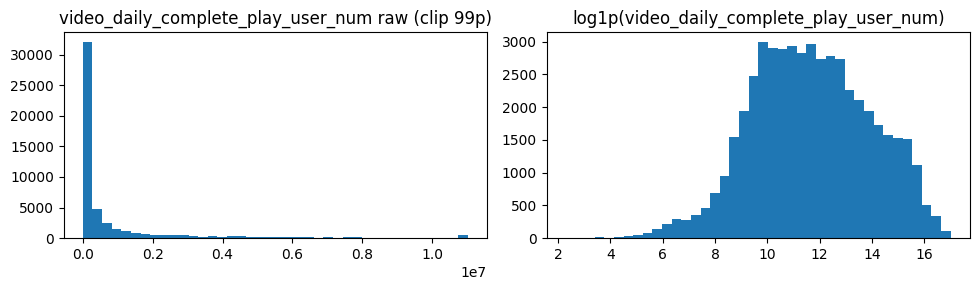

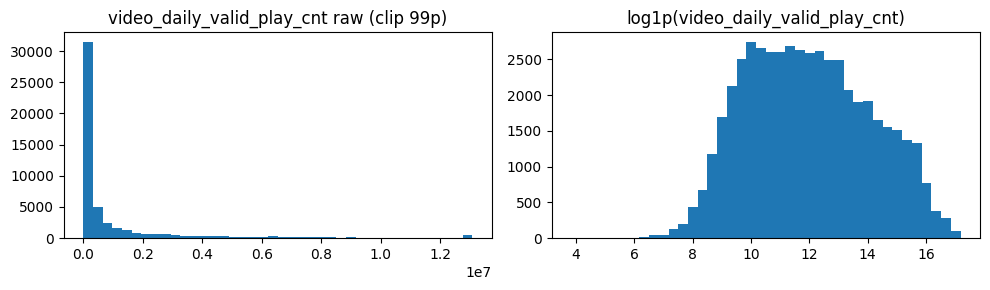

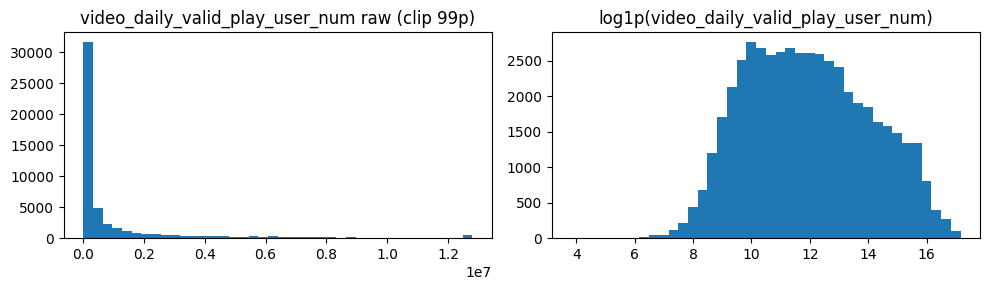

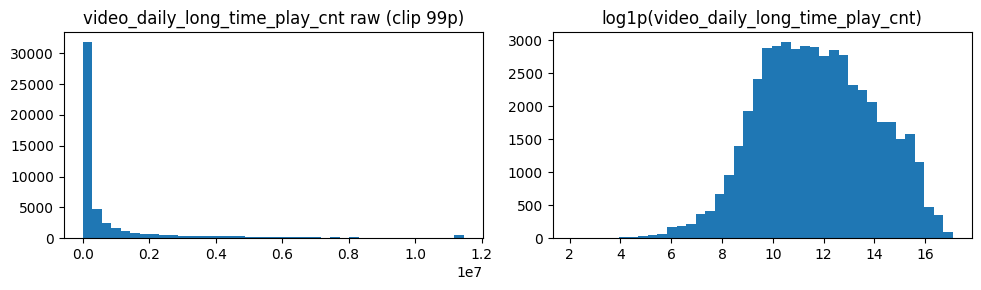

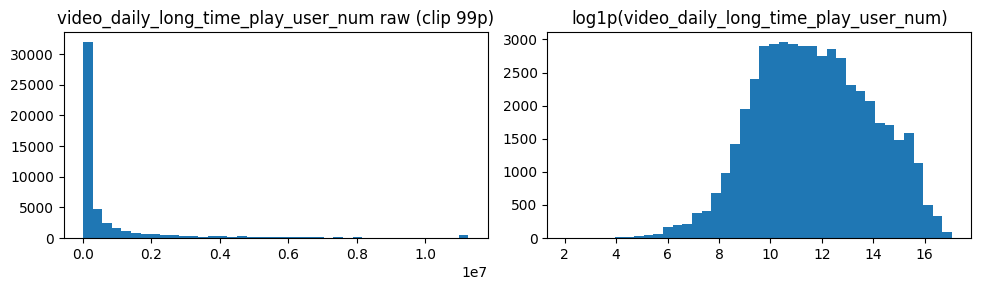

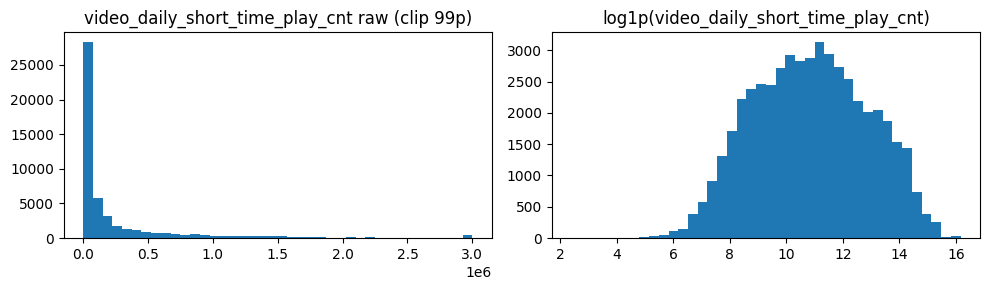

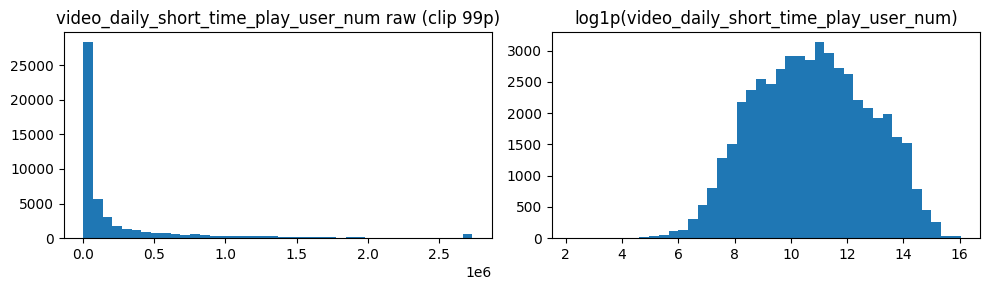

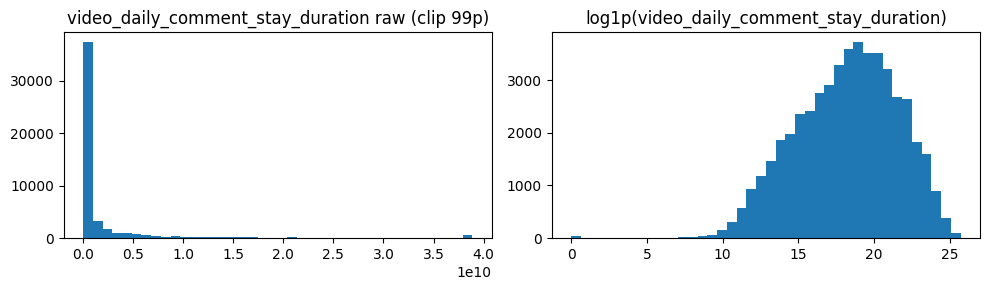

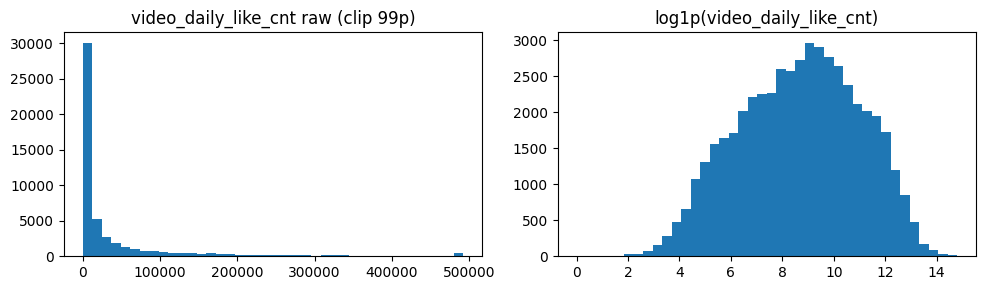

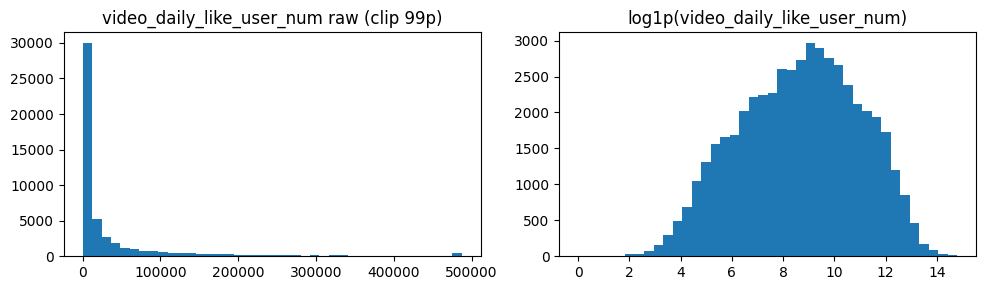

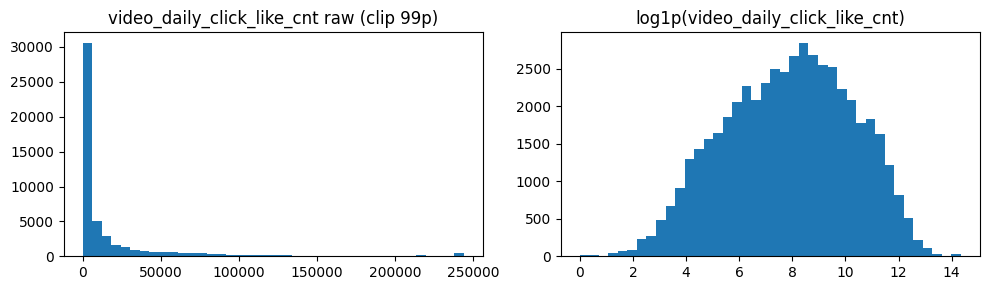

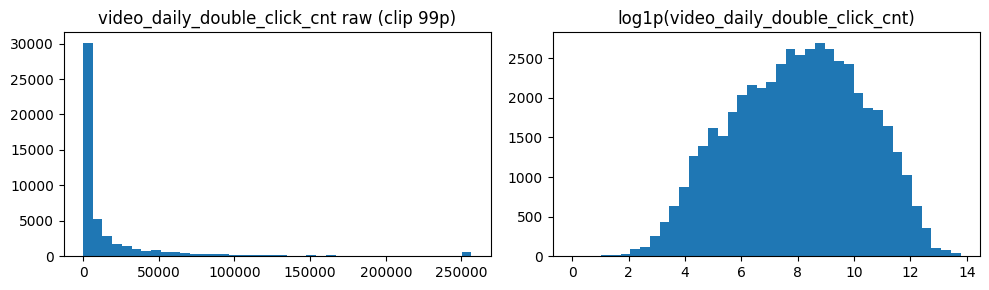

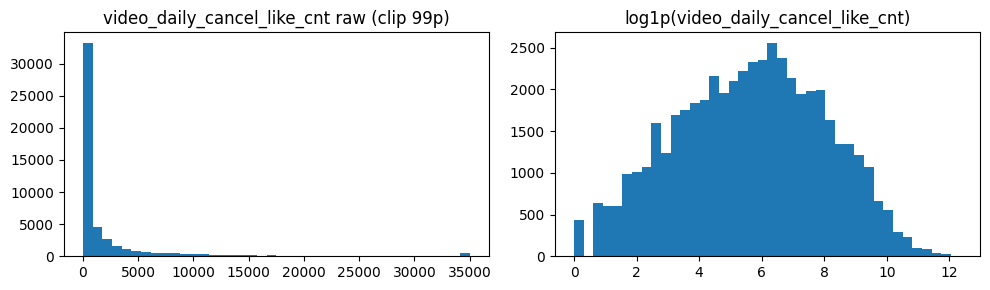

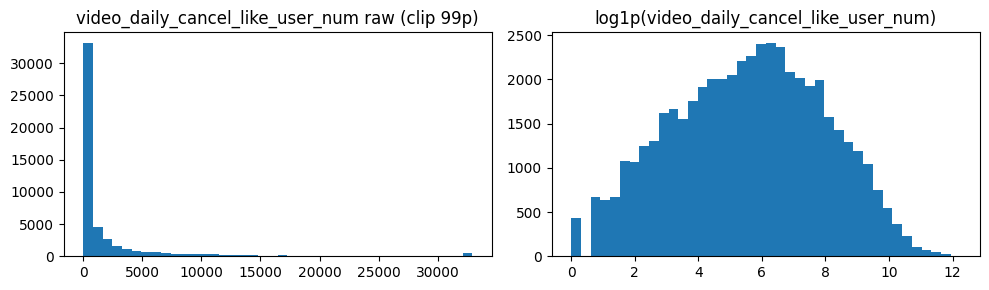

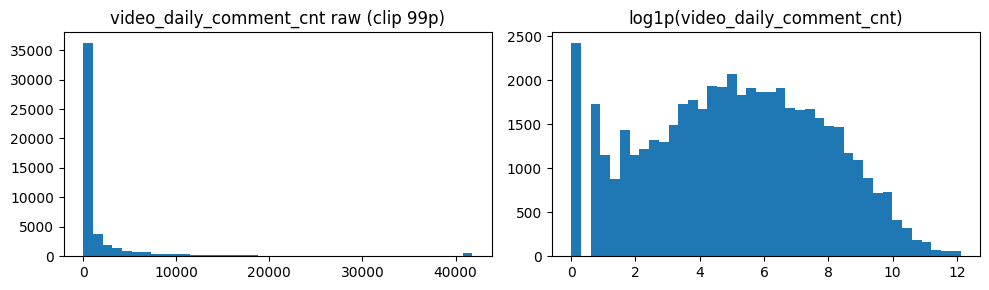

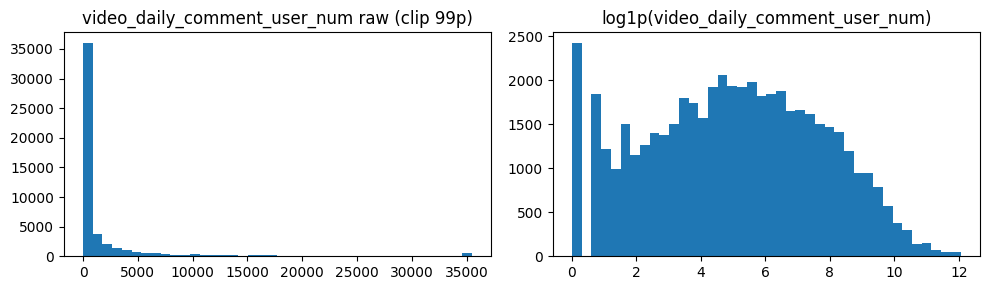

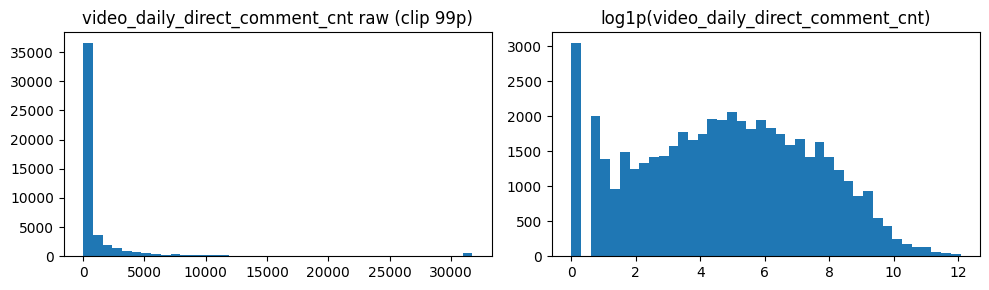

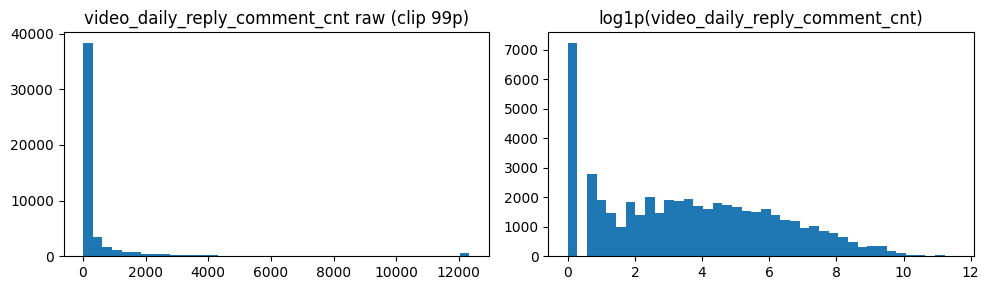

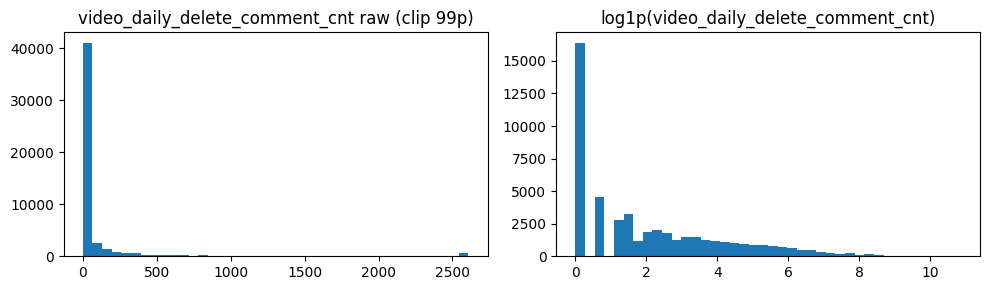

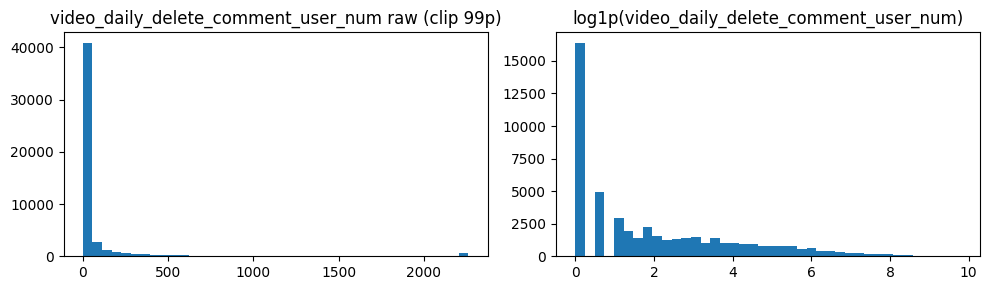

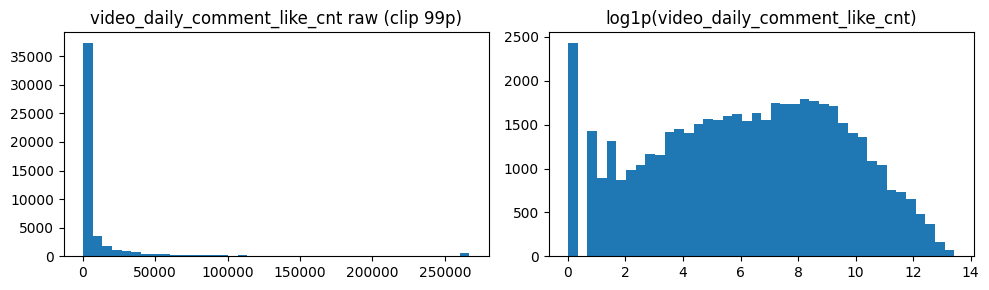

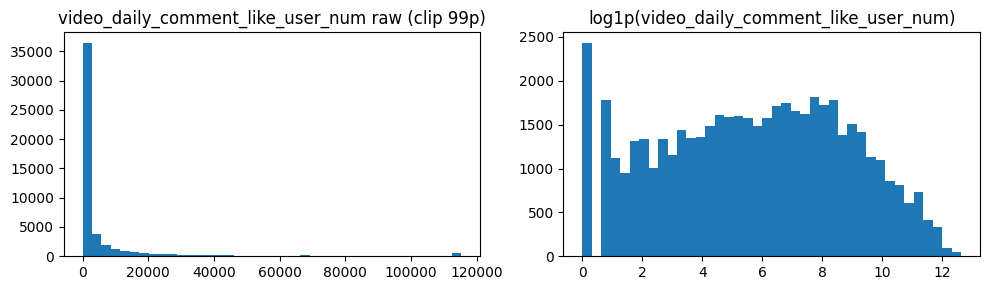

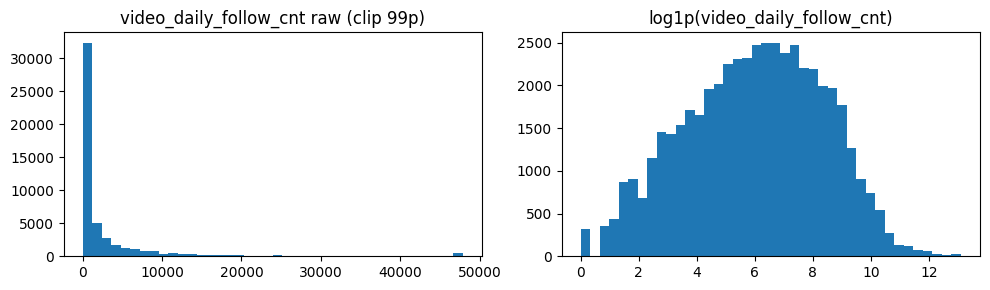

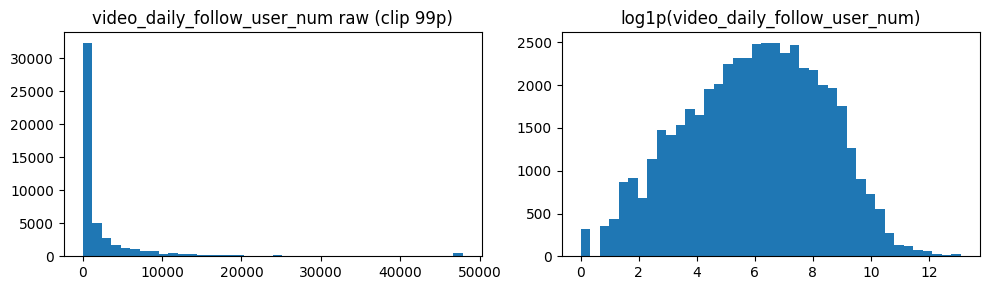

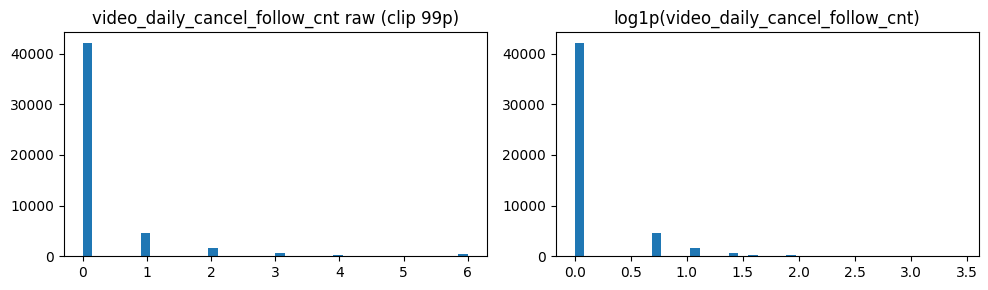

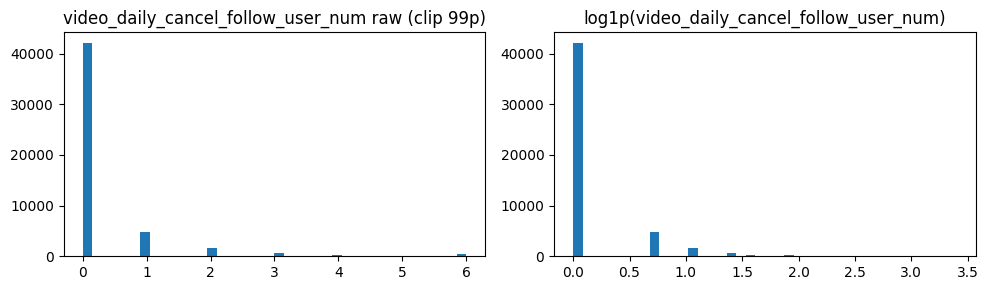

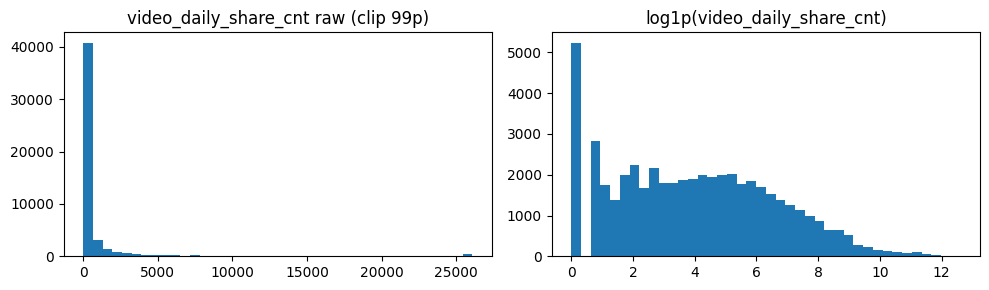

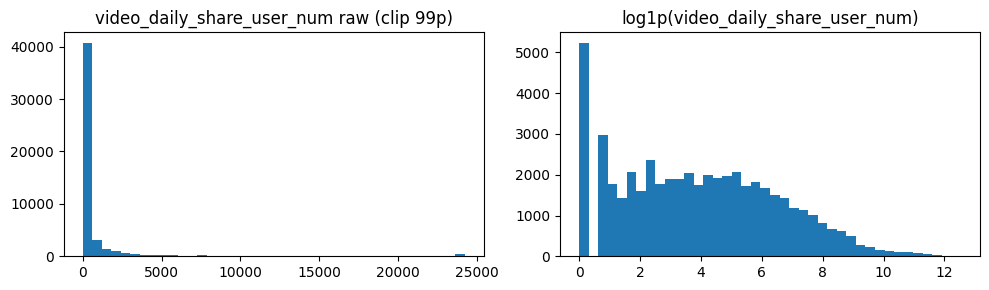

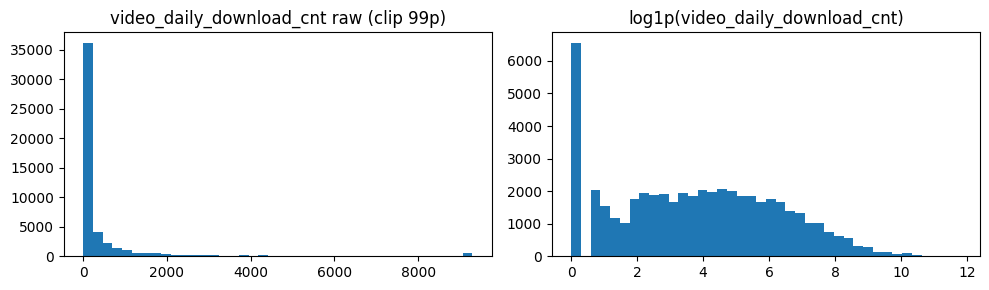

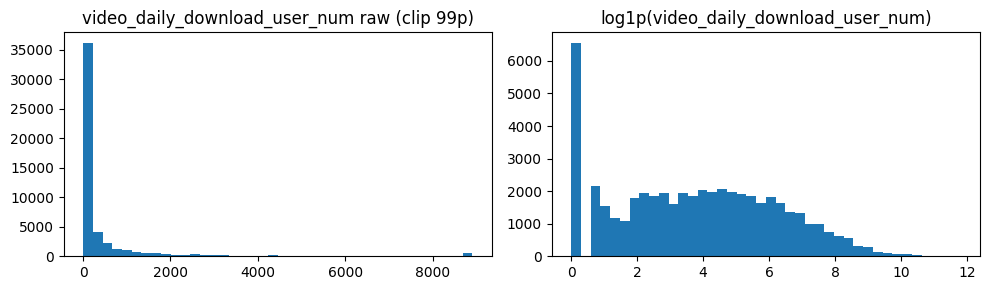

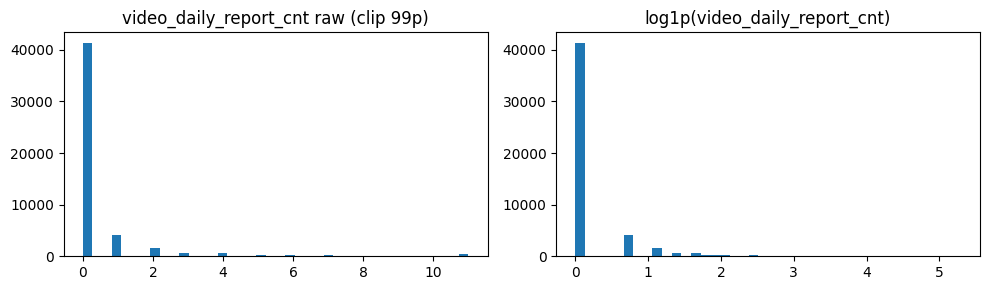

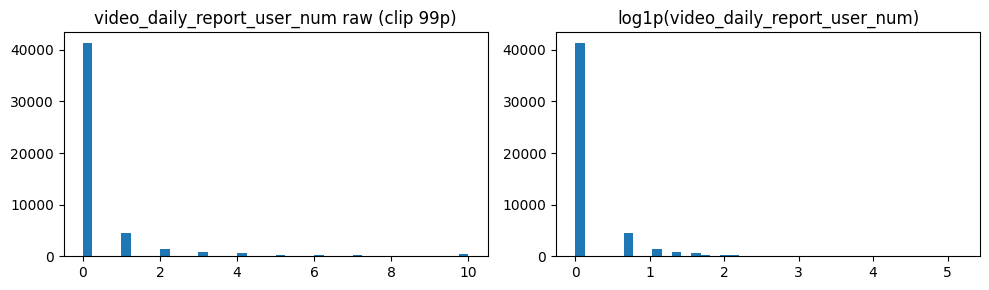

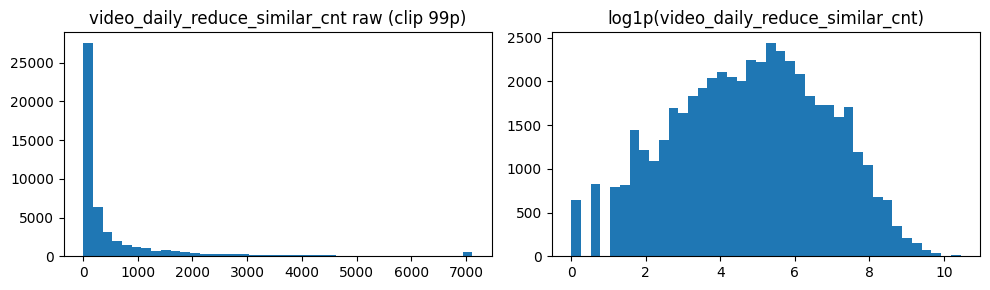

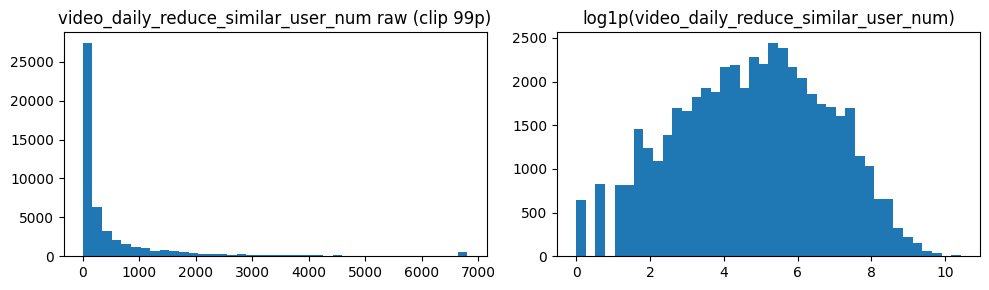

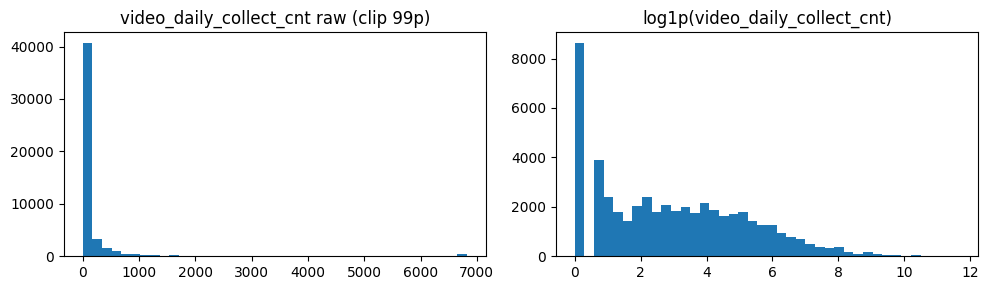

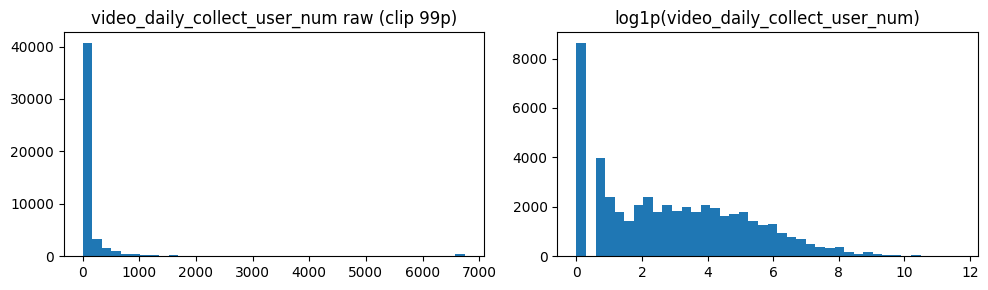

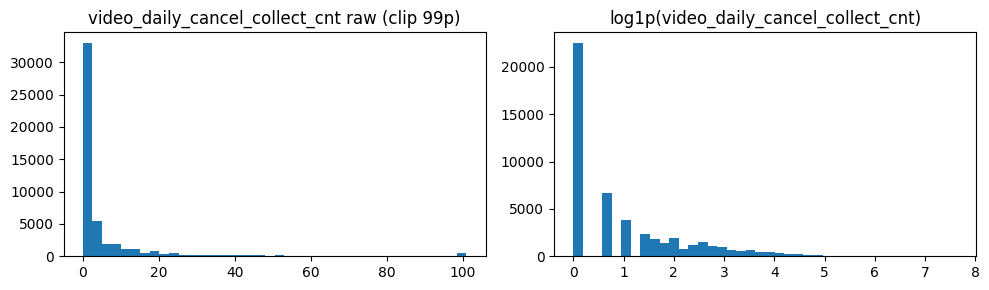

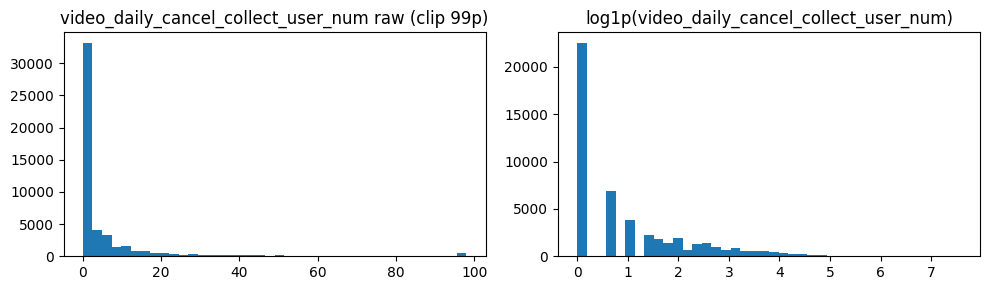

In [9]:
def plot_raw_vs_log(col: str, sample_n: int = 50_000):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    s = s.sample(min(sample_n, len(s)), random_state=0)
    fig, ax = plt.subplots(1, 2, figsize=(10, 3))
    ax[0].hist(s.clip(upper=s.quantile(0.99)), bins=40)
    ax[0].set_title(f"{col} raw (clip 99p)")
    ax[1].hist(np.log1p(s.clip(lower=0)), bins=40)
    ax[1].set_title(f"log1p({col})")
    plt.tight_layout()
    plt.show()

for col in DENSE_CANDIDATES:
    if col in df.columns:
        plot_raw_vs_log(col)

## 3. Categorical features — coverage, cardinality, label lift

Goals:
- Coverage / cardinality / missingness per column
- Which levels carry signal (lift away from 1) vs which are just noise or too rare to trust

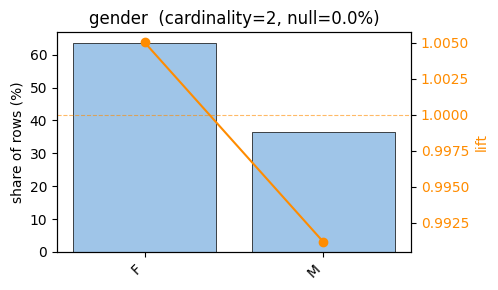

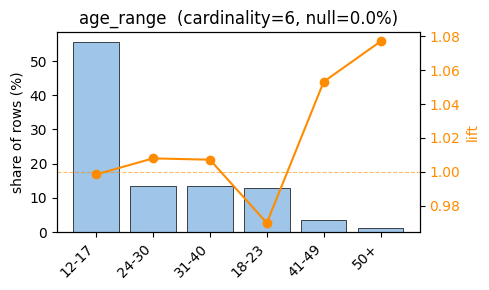

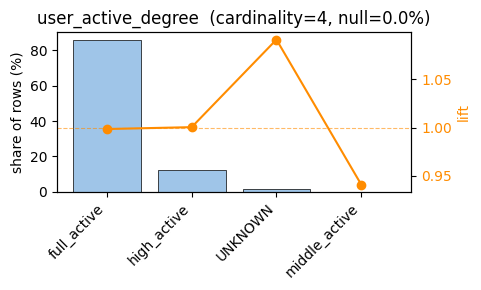

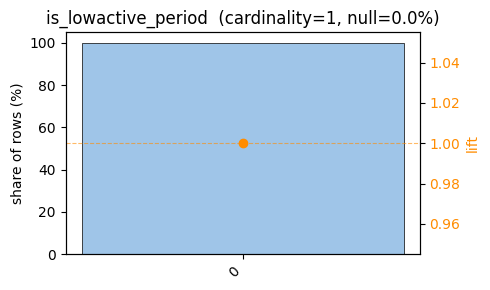

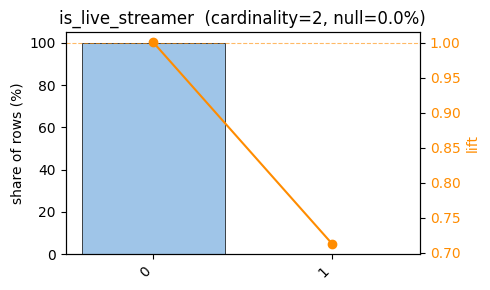

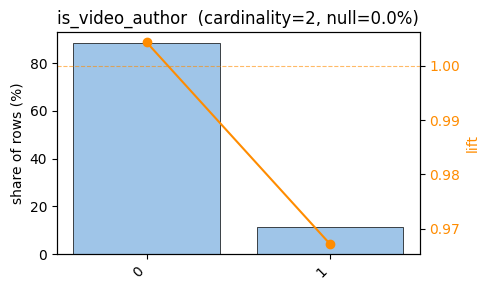

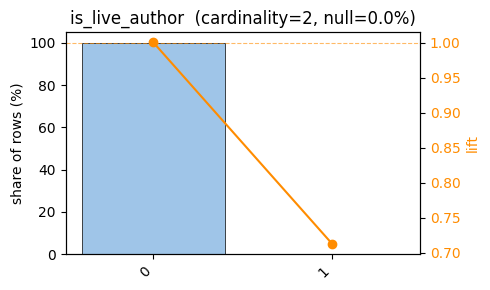

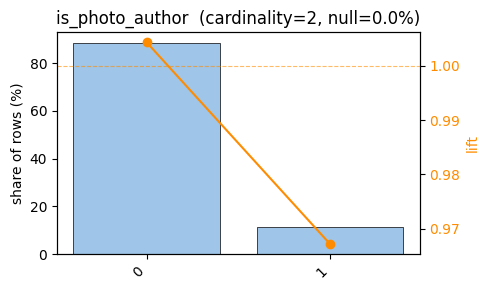

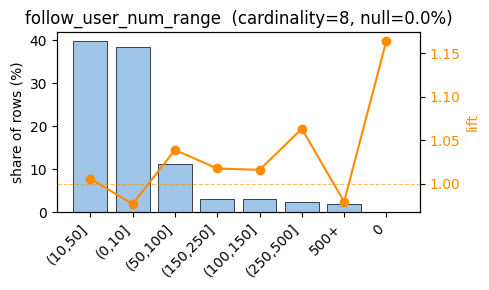

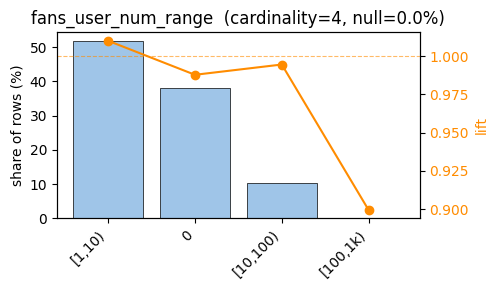

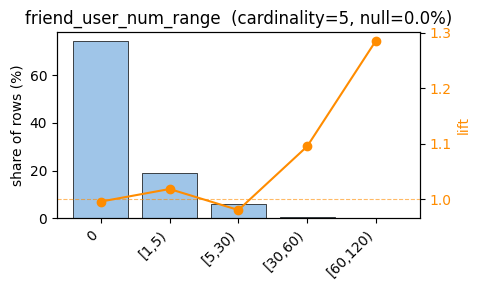

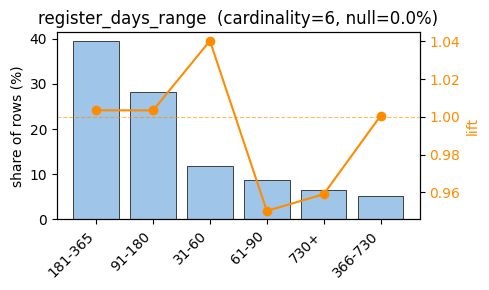

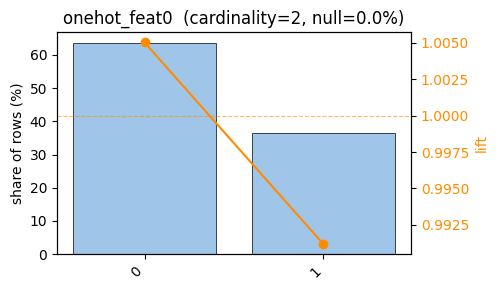

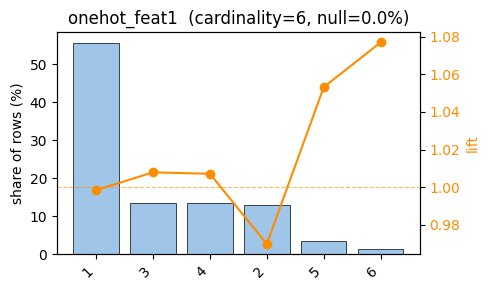

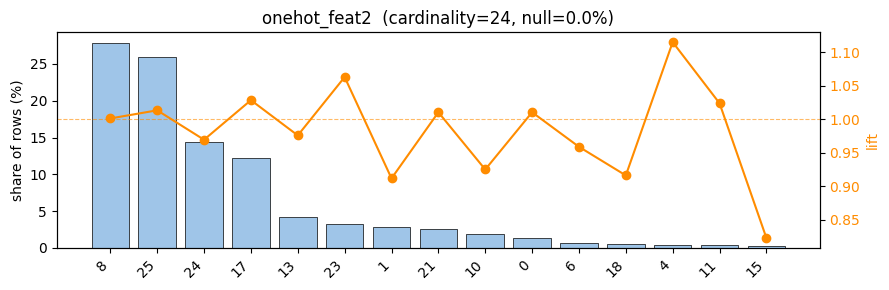

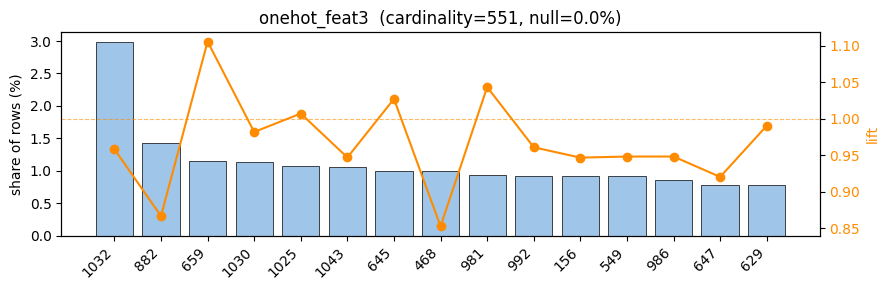

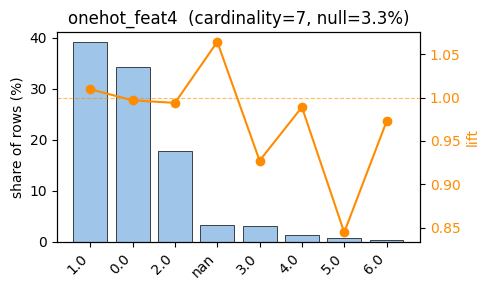

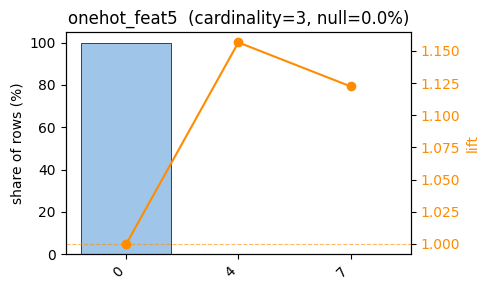

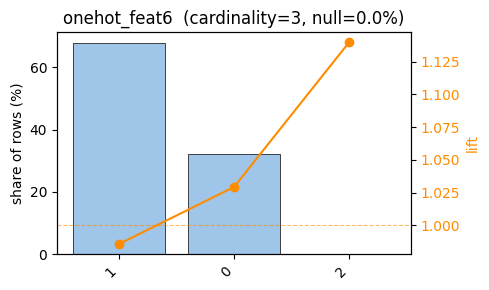

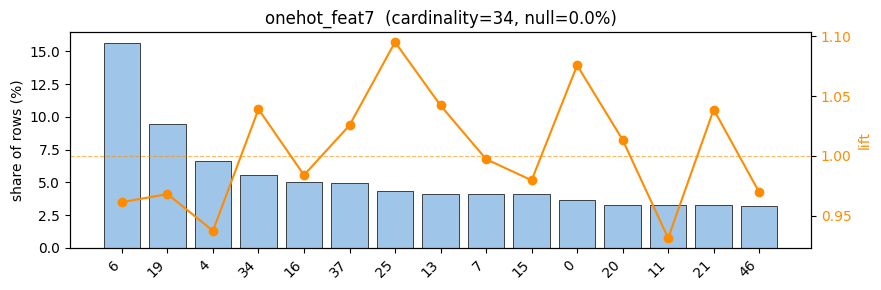

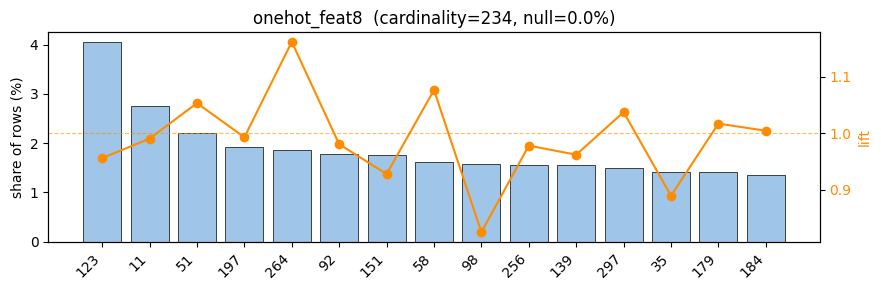

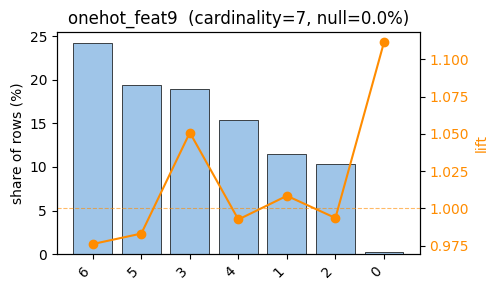

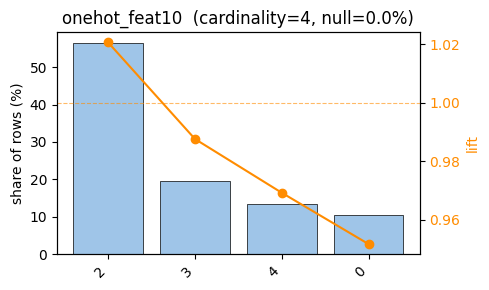

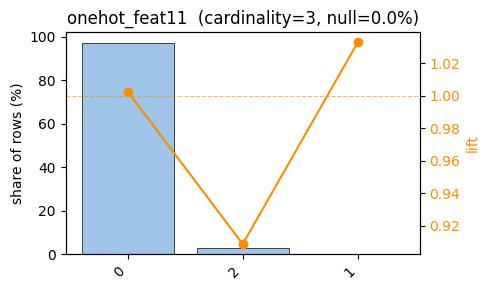

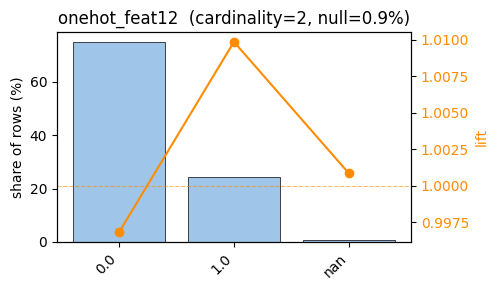

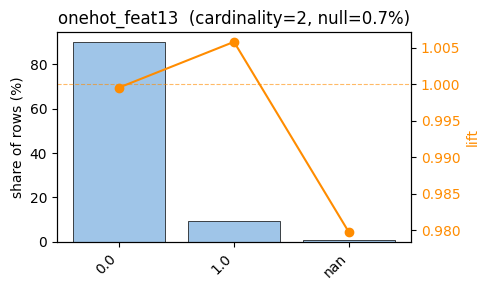

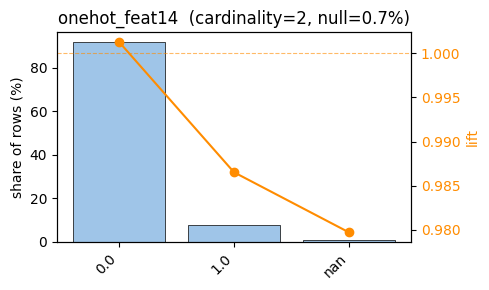

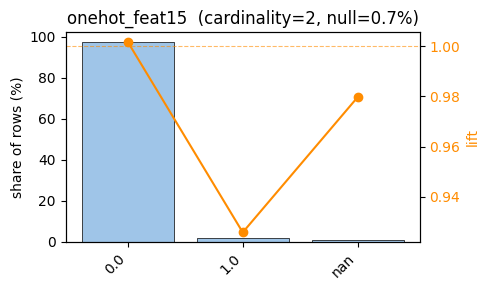

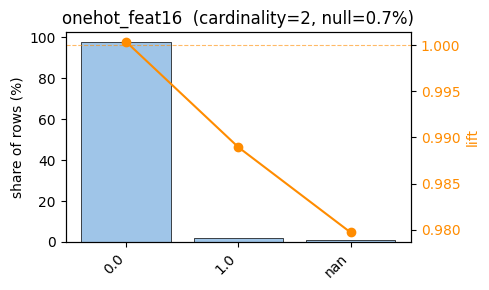

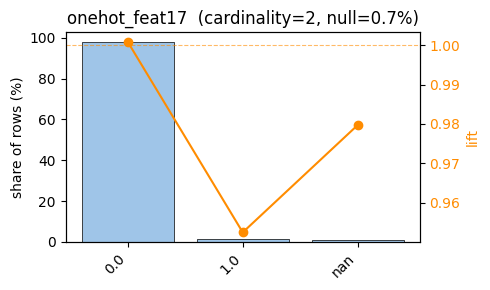

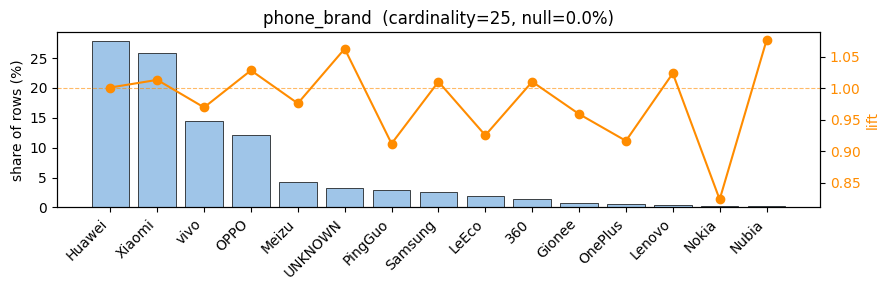

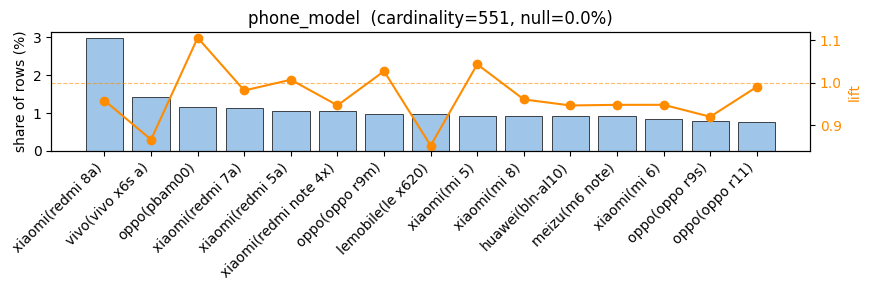

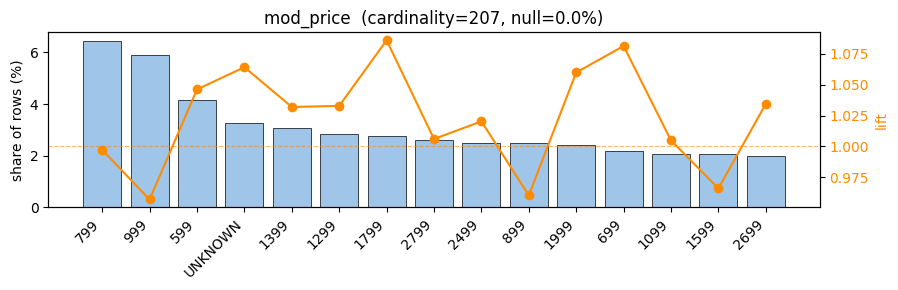

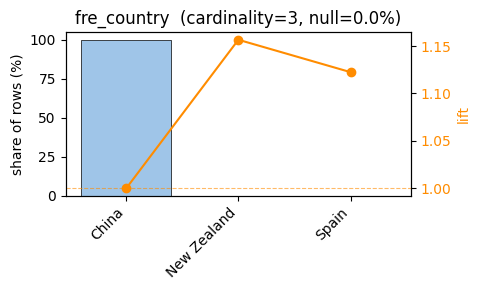

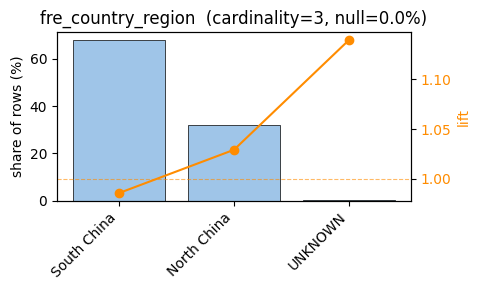

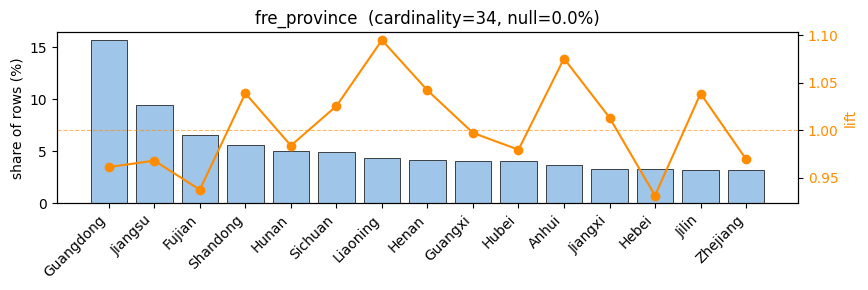

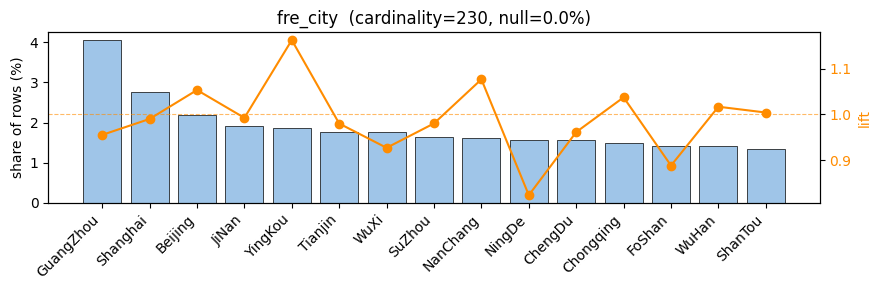

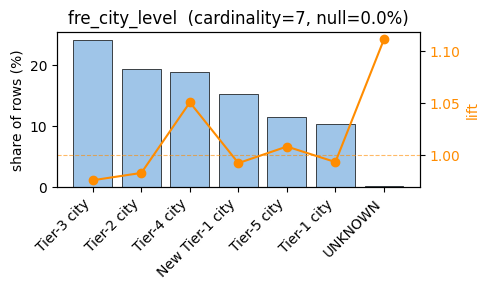

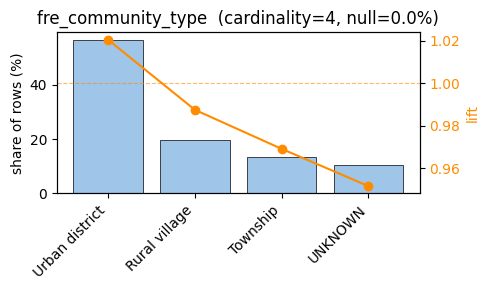

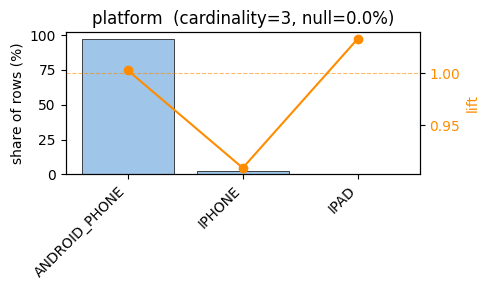

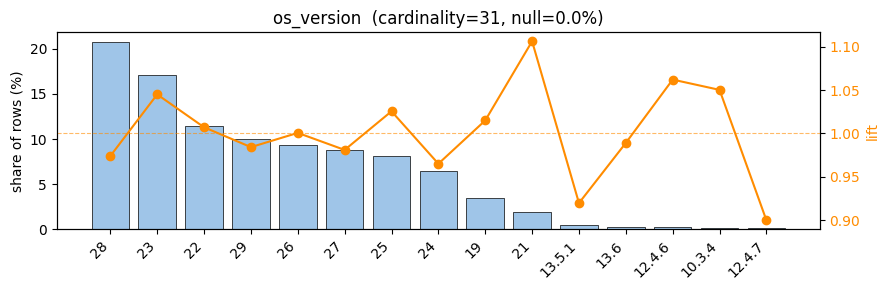

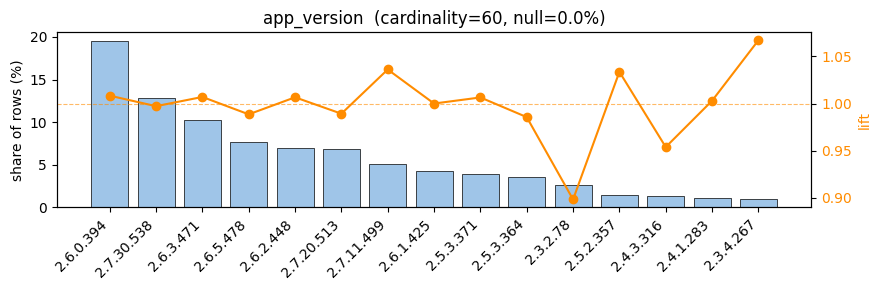

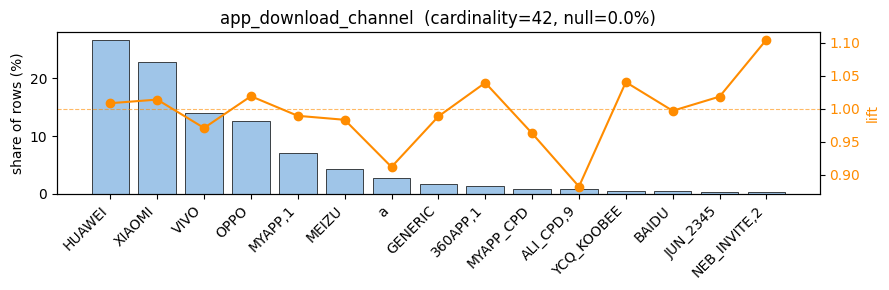

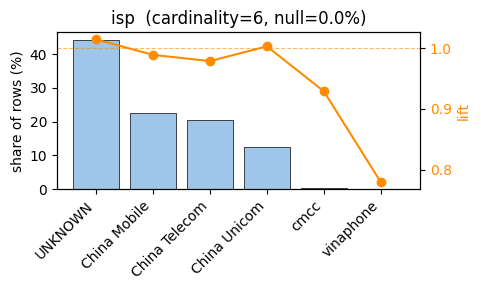

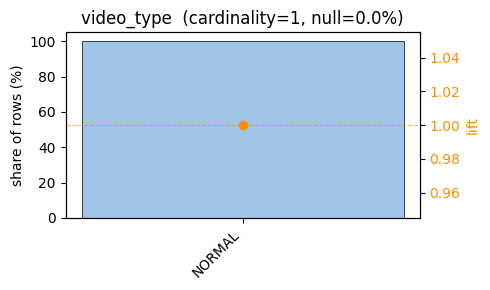

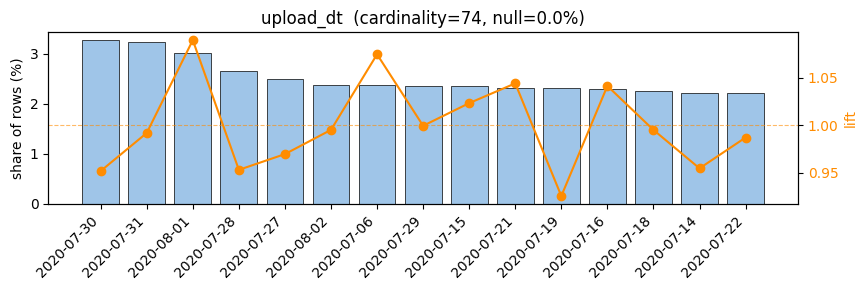

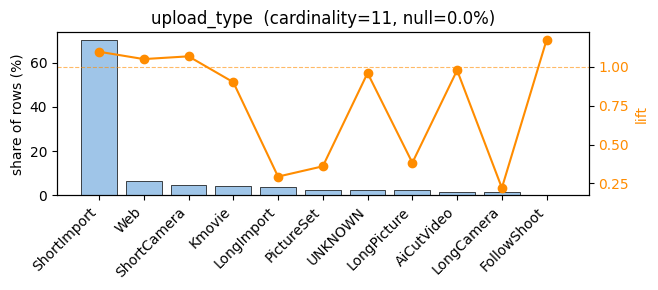

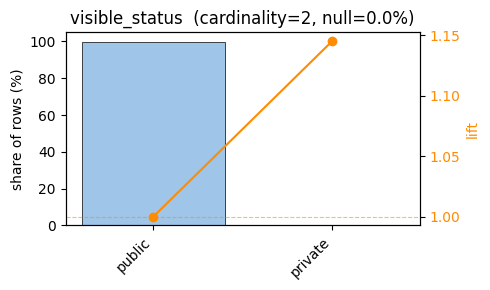

,col,null_frac,cardinality
16,onehot_feat4,0.032575,7
24,onehot_feat12,0.008510,2
25,onehot_feat13,0.007085,2
27,onehot_feat15,0.007085,2
28,onehot_feat16,0.007085,2
29,onehot_feat17,0.007085,2
26,onehot_feat14,0.007085,2
41,app_version,0.000000,60
43,isp,0.000000,6
46,upload_type,0.000000,11


In [10]:
CAT_COLS = [
    "gender",
    "age_range",
    "user_active_degree",
    "is_lowactive_period",
    "is_live_streamer",
    "is_video_author",
    "is_live_author",
    "is_photo_author",
    "follow_user_num_range",
    "fans_user_num_range",
    "friend_user_num_range",
    "register_days_range",
    *[f"onehot_feat{i}" for i in range(18)],
    "phone_brand",
    "phone_model",
    "mod_price",
    "fre_country",
    "fre_country_region",
    "fre_province",
    "fre_city",
    "fre_city_level",
    "fre_community_type",
    "platform",
    "os_version",
    "app_version",
    "app_download_channel",
    "isp",
    "video_type",
    "upload_dt",
    "upload_type",
    "visible_status",
]

global_mean = float(df["watch_ratio"].mean())


def plot_categorical_lift(frame: pd.DataFrame, col: str, label: str = "watch_ratio",
                           min_count: int = 500, top_n: int = 15) -> None:
    """Bars = share of rows per level (left axis); line = lift (right axis,
    dashed ref at 1.0). One glance instead of a cardinality table + a
    per-level lift table for every column.
    """
    g = frame.groupby(col, dropna=False)[label].agg(["mean", "count"])
    g["share"] = g["count"] / len(frame)
    g["lift"] = g["mean"] / global_mean
    g = g[g["count"] >= min_count].sort_values("count", ascending=False).head(top_n)
    if g.empty:
        print(f"{col}: no level clears min_count={min_count}")
        return

    fig, ax1 = plt.subplots(figsize=(max(5, 0.6 * len(g)), 3))
    labels = g.index.astype(str)
    ax1.bar(labels, g["share"] * 100, color="#9fc5e8", edgecolor="k", linewidth=0.5)
    ax1.set_ylabel("share of rows (%)")
    ax1.set_xticks(range(len(labels)))
    ax1.set_xticklabels(labels, rotation=45, ha="right")

    ax2 = ax1.twinx()
    ax2.plot(labels, g["lift"], color="darkorange", marker="o", linewidth=1.5)
    ax2.axhline(1.0, color="darkorange", linestyle="--", linewidth=0.8, alpha=0.6)
    ax2.set_ylabel("lift", color="darkorange")
    ax2.tick_params(axis="y", labelcolor="darkorange")

    null_frac = frame[col].isna().mean()
    ax1.set_title(f"{col}  (cardinality={frame[col].nunique()}, null={null_frac:.1%})")
    plt.tight_layout()
    plt.show()


summary_rows = []
for col in CAT_COLS:
    summary_rows.append({
        "col": col,
        "null_frac": df[col].isna().mean(),
        "cardinality": int(df[col].nunique()),
    })
    plot_categorical_lift(df, col)

pd.DataFrame(summary_rows).sort_values("null_frac", ascending=False)

### 3b. Categorical redundancy — Cramér's V heatmap + exact duplicate check

Goals:
- Which categorical pairs are secretly the same column relabeled?

Cheap broad screen (Cramér's V over all pairs) → expensive exact check
(bijective crosstab) only on flagged pairs 

Findings: [`kuairec_eda_findings.md`](kuairec_eda_findings.md).

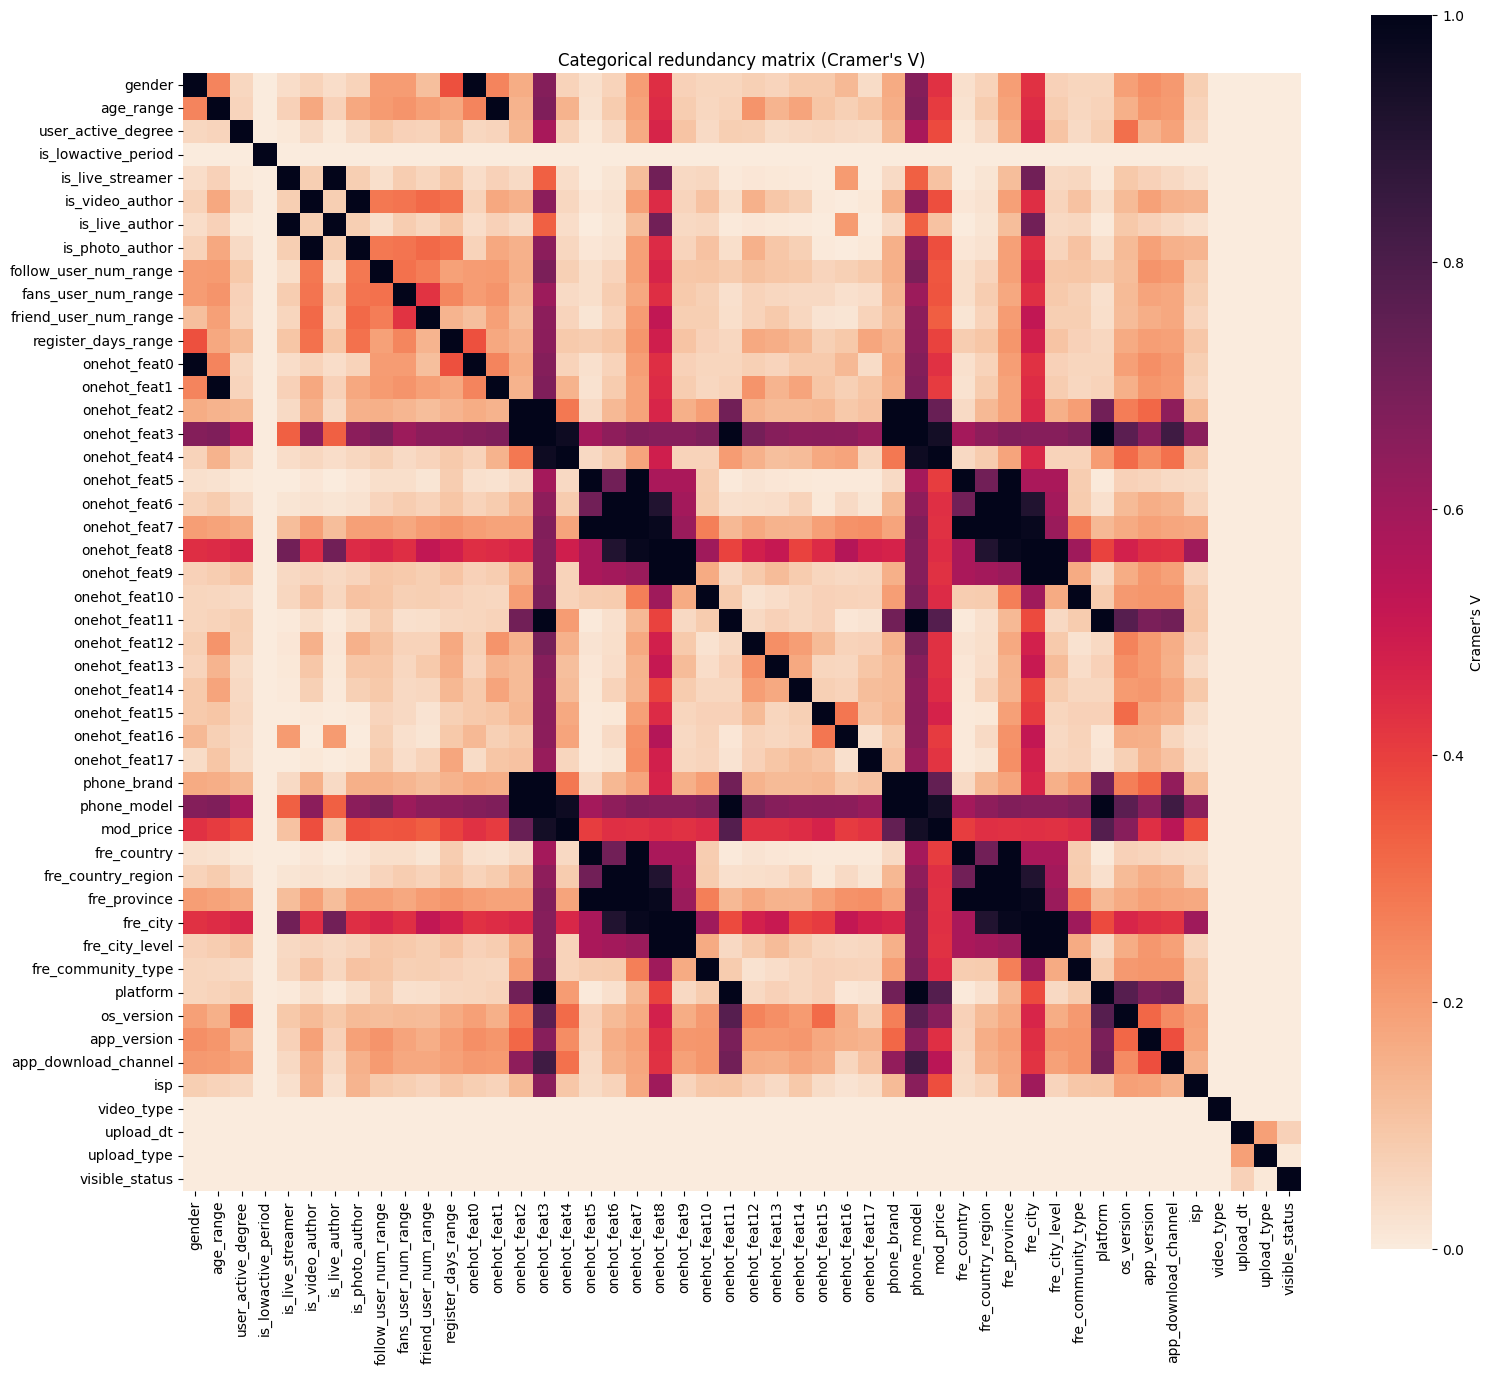

In [11]:
from itertools import combinations

import seaborn as sns


def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """Bias-corrected Cramer's V (Bergsma 2013) — normalized categorical
    association in [0, 1]. Implemented from the raw chi-squared statistic
    (no scipy dependency): chi2 = sum((observed - expected)^2 / expected).
    """
    ct = pd.crosstab(x, y)
    n = float(ct.to_numpy().sum())
    if n == 0:
        return float("nan")
    row_sums = ct.sum(axis=1).to_numpy()
    col_sums = ct.sum(axis=0).to_numpy()
    expected = np.outer(row_sums, col_sums) / n
    expected = np.where(expected == 0, np.nan, expected)
    chi2 = float(np.nansum((ct.to_numpy() - expected) ** 2 / expected))
    r, k = ct.shape
    phi2 = chi2 / n
    # bias correction: raw phi2 is biased upward for small n / large k
    phi2_corr = max(0.0, phi2 - (k - 1) * (r - 1) / (n - 1))
    r_corr = r - (r - 1) ** 2 / (n - 1)
    k_corr = k - (k - 1) ** 2 / (n - 1)
    denom = min(k_corr - 1, r_corr - 1)
    return float(np.sqrt(phi2_corr / denom)) if denom > 0 else 0.0


def cramers_v_matrix(frame: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    mat = pd.DataFrame(np.eye(len(cols)), index=cols, columns=cols)
    for a, b in combinations(cols, 2):
        v = cramers_v(frame[a], frame[b])
        mat.loc[a, b] = mat.loc[b, a] = v
    return mat


v_mat = cramers_v_matrix(df, CAT_COLS)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    v_mat, cmap="rocket_r", vmin=0, vmax=1, square=True,
    cbar_kws={"label": "Cramer's V"}, ax=ax,
)
ax.set_title("Categorical redundancy matrix (Cramer's V)")
plt.tight_layout()
plt.show()

In [12]:
def duplicate_check(frame: pd.DataFrame, a: str, b: str) -> dict:
    """Exact bijective check: does a determine b (and/or vice versa)?

    a_determines_b == 1.0 means every value of `a` maps to exactly one value
    of `b` — i.e. b = f(a) for some function f. If both directions are 1.0,
    a and b carry identical information (just relabeled).
    """
    sub = frame[[a, b]].dropna()
    a_to_b = sub.groupby(a)[b].nunique()
    b_to_a = sub.groupby(b)[a].nunique()
    return {
        "col_a": a,
        "col_b": b,
        "cramers_v": float(v_mat.loc[a, b]),
        "a_determines_b": float((a_to_b == 1).mean()),
        "b_determines_a": float((b_to_a == 1).mean()),
    }


V_THRESHOLD = 0.9
flagged_pairs = [
    (a, b) for a, b in combinations(CAT_COLS, 2) if v_mat.loc[a, b] > V_THRESHOLD
]
print(f"{len(flagged_pairs)} pairs above Cramer's V > {V_THRESHOLD} — running exact bijective check:")

report = pd.DataFrame([duplicate_check(df, a, b) for a, b in flagged_pairs])
report["verdict"] = np.select(
    [
        (report["a_determines_b"] >= 0.99) & (report["b_determines_a"] >= 0.99),
        (report["a_determines_b"] >= 0.99) | (report["b_determines_a"] >= 0.99),
    ],
    ["exact duplicate -> drop one", "coarsening/hierarchy -> keep both (different granularity)"],
    default="strong but not deterministic -> keep both",
)
report.sort_values("cramers_v", ascending=False)

46 pairs above Cramer's V > 0.9 — running exact bijective check:


,col_a,col_b,cramers_v,a_determines_b,b_determines_a,verdict
0,gender,onehot_feat0,1.000000,1.000000,1.000000,exact duplicate -> drop one
26,onehot_feat7,fre_province,1.000000,1.000000,1.000000,exact duplicate -> drop one
16,onehot_feat5,fre_country,1.000000,1.000000,1.000000,exact duplicate -> drop one
35,onehot_feat10,fre_community_type,1.000000,1.000000,1.000000,exact duplicate -> drop one
1,age_range,onehot_feat1,1.000000,1.000000,1.000000,exact duplicate -> drop one
37,onehot_feat11,platform,1.000000,1.000000,1.000000,exact duplicate -> drop one
10,onehot_feat3,phone_model,1.000000,1.000000,1.000000,exact duplicate -> drop one
3,is_video_author,is_photo_author,1.000000,1.000000,1.000000,exact duplicate -> drop one
2,is_live_streamer,is_live_author,1.000000,1.000000,1.000000,exact duplicate -> drop one
20,onehot_feat6,fre_country_region,1.000000,1.000000,1.000000,exact duplicate -> drop one


## 4. Cross features — support + lift vs main effects

Goals:
- Is a hand-picked binary cross worth its own memorized slot, beyond what its parent fields already give a model?

In [ ]:
from data.kuairec_preprocessor import WIDE_CROSS_SPECS

gmean = float(df["watch_ratio"].mean())

rows = []
for spec in WIDE_CROSS_SPECS:
    mask = pd.Series(True, index=df.index)
    for k, v in spec["input_features"].items():
        mask &= df[k].astype(str) == str(v)
    support = float(mask.mean())
    mean_y = float(df.loc[mask, "watch_ratio"].mean()) if mask.any() else float("nan")
    rows.append({
        "cross": spec["name"],
        "support": support,
        "n": int(mask.sum()),
        "mean_y": mean_y,
        "lift": mean_y / gmean if gmean else float("nan"),
    })
pd.DataFrame(rows)

### Automatic cross-candidate mining (interaction lift)

Goals:
- Screen for cross-feature synergy automatically instead of only hand-picking pairs.

```
interaction_lift = lift(a, b jointly) / (lift(a) * lift(b))
```

`≈ 1` → the joint lift is just the two marginals multiplying together, no
cross term needed. `>> 1` or `<< 1` → real synergy/conflict only a cross
term (or the deep path) can capture. 

Findings: [`kuairec_eda_findings.md`](kuairec_eda_findings.md).

In [13]:
def cross_candidates(
    frame: pd.DataFrame,
    col_a: str,
    col_b: str,
    label: str = "watch_ratio",
    min_count: int = 500,
    top_k: int = 15,
) -> pd.DataFrame:
    """Rank (col_a, col_b) category pairs by interaction_lift, filtered by support."""
    gmean = float(frame[label].mean())
    lift_a = frame.groupby(col_a)[label].mean() / gmean
    lift_b = frame.groupby(col_b)[label].mean() / gmean

    joint = frame.groupby([col_a, col_b])[label].agg(["mean", "count"])
    joint = joint[joint["count"] >= min_count].copy()
    joint["lift_joint"] = joint["mean"] / gmean

    idx_a = joint.index.get_level_values(0)
    idx_b = joint.index.get_level_values(1)
    joint["lift_expected"] = lift_a.reindex(idx_a).to_numpy() * lift_b.reindex(idx_b).to_numpy()
    joint["interaction_lift"] = joint["lift_joint"] / joint["lift_expected"]

    return joint.sort_values("interaction_lift", ascending=False).head(top_k)


# A few user-side x user-side and user-side x item-side pairs to try.
# Swap in your own CAT_COLS pairs (or a bucketed dense column) to search more broadly.
for col_a, col_b in [
    ("gender", "age_range"),
    ("age_range", "register_days_range"),
    ("user_active_degree", "register_days_range"),
    ("age_range", "upload_type"),
    ("gender", "user_active_degree"),
    ("gender", "fre_city_level"),
    ("age_range", "fre_city_level"),
    ("age_range", "platform"),
    ("user_active_degree", "platform"),
    ("gender", "isp"),
    ("register_days_range", "follow_user_num_range"),
    ("register_days_range", "upload_type"),
    ("follow_user_num_range", "fans_user_num_range"),
    ("user_active_degree", "upload_type"),
    ("age_range", "fre_country_region"),
]:
    print(f"\n=== {col_a} x {col_b} (top interaction_lift, min_count>=500) ===")
    display(cross_candidates(df, col_a, col_b))


=== gender x age_range (top interaction_lift, min_count>=500) ===


mean    count  lift_joint  lift_expected  \
gender age_range                                                 
M      50+        1.059490    28840    1.162518       1.067510   
F      41-49      1.028773    85761    1.128813       1.058491   
M      18-23      0.884709   292446    0.970740       0.961209   
       24-30      0.916911   273444    1.006073       0.999004   
F      31-40      0.926951   267641    1.017090       1.012190   
M      31-40      0.910557   332977    0.999101       0.998239   
F      12-17      0.913840  1859969    1.002704       1.003459   
       24-30      0.919944   328301    1.009401       1.012965   
M      12-17      0.898625   639950    0.986009       0.989629   
F      18-23      0.882911   290127    0.968767       0.974642   
M      41-49      0.871072    66582    0.955777       1.043903   
F      50+        0.902801    28540    0.990592       1.082429   

                  interaction_lift  
gender age_range                    
M      50+                1.088999  
F      41-49              1.066436  
M      18-23              1.009916  
       24-30              1.007077  
F      31-40              1.004841  
M      31-40              1.000864  
F      12-17              0.999248  
       24-30              0.996481  
M      12-17              0.996343  
F      18-23              0.993973  
M      41-49              0.915580  
F      50+                0.915157


=== age_range x register_days_range (top interaction_lift, min_count>=500) ===


mean   count  lift_joint  lift_expected  \
age_range register_days_range                                                
31-40     31-60                1.070643    6398    1.174755       1.047693   
18-23     366-730              0.966315   37986    1.060282       0.970272   
41-49     730+                 1.005779   12767    1.103583       1.009967   
50+       181-365              1.071622   28769    1.175829       1.080740   
          91-180               1.041725    6381    1.143025       1.080642   
24-30     366-730              0.964463   31686    1.058249       1.008424   
31-40     91-180               0.956036  124117    1.049003       1.010519   
24-30     91-180               0.954533  140814    1.047354       1.011293   
18-23     730+                 0.876845   63545    0.962111       0.929961   
41-49     181-365              0.987362   92107    1.083375       1.056840   
12-17     61-90                0.878441  287837    0.963862       0.948571   
18-23     91-180               0.897427  140035    0.984695       0.973033   
12-17     31-60                0.955246  428694    1.048136       1.038656   
41-49     91-180               0.969327   15822    1.063587       1.056744   
31-40     366-730              0.923437   31639    1.013235       1.007651   

                               interaction_lift  
age_range register_days_range                    
31-40     31-60                        1.121278  
18-23     366-730                      1.092768  
41-49     730+                         1.092692  
50+       181-365                      1.087985  
          91-180                       1.057728  
24-30     366-730                      1.049410  
31-40     91-180                       1.038084  
24-30     91-180                       1.035658  
18-23     730+                         1.034571  
41-49     181-365                      1.025108  
12-17     61-90                        1.016120  
18-23     91-180                       1.011985  
12-17     31-60                        1.009128  
41-49     91-180                       1.006476  
31-40     366-730                      1.005541


=== user_active_degree x register_days_range (top interaction_lift, min_count>=500) ===


...

mean    count  lift_joint  \
follow_user_num_range fans_user_num_range                                  
0                     [1,10)               1.360317     3214    1.492598   
(50,100]              0                    1.055437    37951    1.158070   
500+                  0                    0.993231     9592    1.089815   
(100,150]             [10,100)             0.985352    47615    1.081170   
(250,500]             [10,100)             1.007864    41272    1.105871   
(150,250]             [1,10)               0.958626    82266    1.051845   
(0,10]                0                    0.891450  1019030    0.978136   
                      [10,100)             0.894012    28567    0.980948   
(10,50]               0                    0.906722   590098    0.994894   
(50,100]              [1,10)               0.956734   343283    1.049769   
(10,50]               [1,10)               0.926069  1054703    1.016122   
500+                  [1,10)               0.900753    31753    0.988345   
(0,10]                [1,10)               0.887872   680992    0.974211   
(10,50]               [10,100)             0.888123   145632    0.974486   
(150,250]             [10,100)             0.897566    38013    0.984848   

                                           lift_expected  interaction_lift  
follow_user_num_range fans_user_num_range                                   
0                     [1,10)                    1.176614          1.268554  
(50,100]              0                         1.026277          1.128418  
500+                  0                         0.967445          1.126489  
(100,150]             [10,100)                  1.010491          1.069945  
(250,500]             [10,100)                  1.057448          1.045792  
(150,250]             [1,10)                    1.027866          1.023329  
(0,10]                0                         0.964803          1.013820  
                      [10,100)                  0.971361          1.009869  
(10,50]               0                         0.993553          1.001349  
(50,100]              [1,10)                    1.049370          1.000380  
(10,50]               [1,10)                    1.015909          1.000210  
500+                  [1,10)                    0.989213          0.999122  
(0,10]                [1,10)                    0.986512          0.987531  
(10,50]               [10,100)                  1.000307          0.974188  
(150,250]             [10,100)                  1.012080          0.973092


=== user_active_degree x upload_type (top interaction_lift, min_count>=500) ===


mean   count  lift_joint  lift_expected  \
user_active_degree upload_type                                                
UNKNOWN            LongPicture  0.469388    1535    0.515032       0.418110   
                   UNKNOWN      1.031223    1624    1.131502       1.048302   
                   PictureSet   0.374773    1744    0.411217       0.393226   
                   LongImport   0.304584    2548    0.334203       0.320912   
high_active        LongPicture  0.363711   12656    0.399079       0.383439   
                   PictureSet   0.337054   14465    0.369830       0.360618   
                   Kmovie       0.843200   24368    0.925195       0.902358   
                   LongImport   0.273913   20996    0.300549       0.294301   
UNKNOWN            ShortCamera  1.074344    3047    1.178816       1.165585   
middle_active      ShortImport  0.947609    4448    1.039757       1.033541   
high_active        ShortCamera  0.978219   25614    1.073343       1.068930   
full_active        AiCutVideo   0.893729   66010    0.980638       0.977361   
                   Web          0.958017  246339    1.051177       1.049192   
                   LongCamera   0.201588   62114    0.221191       0.220970   
high_active        UNKNOWN      0.876649   13563    0.961897       0.961373   

                                interaction_lift  
user_active_degree upload_type                    
UNKNOWN            LongPicture          1.231811  
                   UNKNOWN              1.079366  
                   PictureSet           1.045753  
                   LongImport           1.041416  
high_active        LongPicture          1.040791  
                   PictureSet           1.025544  
                   Kmovie               1.025308  
                   LongImport           1.021230  
UNKNOWN            ShortCamera          1.011351  
middle_active      ShortImport          1.006014  
high_active        ShortCamera          1.004129  
full_active        AiCutVideo           1.003353  
                   Web                  1.001892  
                   LongCamera           1.001000  
high_active        UNKNOWN              1.000545


=== age_range x fre_country_region (top interaction_lift, min_count>=500) ===


mean    count  lift_joint  lift_expected  \
age_range fre_country_region                                                 
50+       South China         1.075522    31868    1.180108       1.061786   
18-23     North China         0.950229   172014    1.042632       0.998194   
41-49     South China         0.958012    69935    1.051171       1.038305   
31-40     South China         0.914602   368807    1.003540       0.992886   
24-30     South China         0.910218   411207    0.998729       0.993647   
12-17     North China         0.940351   736677    1.031793       1.027708   
          UNKNOWN             1.038565     6383    1.139558       1.137769   
          South China         0.896728  1756859    0.983928       0.984322   
24-30     North China         0.936581   190538    1.027656       1.037444   
18-23     South China         0.855987   410559    0.939225       0.956054   
31-40     North China         0.923048   231811    1.012808       1.036649   
41-49     North China         0.961408    82408    1.054897       1.084070   
50+       North China         0.864178    25512    0.948213       1.108586   

                              interaction_lift  
age_range fre_country_region                    
50+       South China                 1.111437  
18-23     North China                 1.044518  
41-49     South China                 1.012392  
31-40     South China                 1.010730  
24-30     South China                 1.005115  
12-17     North China                 1.003975  
          UNKNOWN                     1.001572  
          South China                 0.999600  
24-30     North China                 0.990566  
18-23     South China                 0.982397  
31-40     North China                 0.977001  
41-49     North China                 0.973090  
50+       North China                 0.855335

In [ ]:
# Systematic scan: instead of only the hand-picked pairs above, sweep every
# pair of low-cardinality, non-duplicate categoricals and keep each pair's
# single best (highest |log interaction_lift|) segment
DUPLICATE_ANON_COLS = {f"onehot_feat{i}" for i in [0, 1, 2, 3, 5, 6, 7, 8, 9, 10, 11]}
CONSTANT_OR_DUP_COLS = DUPLICATE_ANON_COLS | {"video_type", "is_lowactive_period", "is_live_streamer"}
MAX_CROSS_CARDINALITY = 12

CROSS_SCAN_COLS = [
    c for c in CAT_COLS
    if c not in CONSTANT_OR_DUP_COLS and df[c].nunique(dropna=True) <= MAX_CROSS_CARDINALITY
]
print(f"{len(CROSS_SCAN_COLS)} columns eligible for cross mining:", CROSS_SCAN_COLS)


def best_cross_per_pair(frame: pd.DataFrame, cols: list[str], label: str = "watch_ratio",
                         min_count: int = 2000) -> pd.DataFrame:
    rows = []
    for a, b in combinations(cols, 2):
        cand = cross_candidates(frame, a, b, label=label, min_count=min_count, top_k=len(frame))
        if cand.empty:
            continue
        cand = cand.replace([np.inf, -np.inf], np.nan).dropna(subset=["interaction_lift"])
        if cand.empty:
            continue
        # rank by distance from 1.0 in log-space so strong "conflict" segments
        # (interaction_lift << 1) surface alongside strong synergy (>> 1)
        top = cand.iloc[np.log(cand["interaction_lift"]).abs().argmax()]
        rows.append({
            "col_a": a, "val_a": top.name[0],
            "col_b": b, "val_b": top.name[1],
            "count": int(top["count"]),
            "lift_joint": float(top["lift_joint"]),
            "interaction_lift": float(top["interaction_lift"]),
        })
    out = pd.DataFrame(rows)
    out["abs_log_interaction"] = np.log(out["interaction_lift"]).abs()
    return out.sort_values("abs_log_interaction", ascending=False)


cross_scan = best_cross_per_pair(df, CROSS_SCAN_COLS, min_count=2000)
cross_scan.head(30)

## 5. Split audit — train / validation / test

Goals:
- Does any feature's missing rate or mean shift across splits? That's the
  sharpest signal for a broken temporal split or an ETL join bug.

This audit caught a real one: rows with a missing `timestamp` (~3.9%) were
sorted to the tail by `sort_values(..., na_position="last")` before the
80/10/10 split, so they all landed in `test`. 

Full write-up in [`kuairec_eda_findings.md`](kuairec_eda_findings.md).

In [ ]:
# Missing rate + post-transform mean per split. Sparse cols are already
# factorized (NaN -> index 0), so "missing" = value == 0, not isna();
from data.kuairec_preprocessor import SPARSE_FEATURE_COLS, WIDE_CROSS_SPECS 

train = pd.read_parquet(EXTRACT / "train.parquet")
val = pd.read_parquet(EXTRACT / "val.parquet")
test = pd.read_parquet(EXTRACT / "test.parquet")
SPLITS = [("train", train), ("val", val), ("test", test)]

CROSS_COLS = [spec["name"] for spec in WIDE_CROSS_SPECS]


def audit_col(col: str, kind: str) -> list[dict]:
    rows = []
    for split_name, frame in SPLITS:
        if col not in frame.columns:
            continue
        s = frame[col]
        missing_rate = float((s == 0).mean()) if kind == "sparse" else float(s.isna().mean())
        numeric = pd.to_numeric(s, errors="coerce")
        rows.append({
            "col": col, "kind": kind, "split": split_name, "n": len(frame),
            "missing_rate": missing_rate,
            "mean": float(numeric.mean()),
            "std": float(numeric.std()),
            "p99": float(numeric.quantile(0.99)),
        })
    return rows


audit_rows = []
for col in SPARSE_FEATURE_COLS:
    audit_rows += audit_col(col, "sparse")
for col in DENSE_CANDIDATES:
    audit_rows += audit_col(col, "dense")
for col in CROSS_COLS:
    audit_rows += audit_col(col, "dense")  # crosses are float 0/1, no reserved index
audit = pd.DataFrame(audit_rows)

# --- Missing-rate drift: the sharpest signal for a broken join/split ---
missing_pivot = audit.pivot(index="col", columns="split", values="missing_rate")[["train", "val", "test"]]
missing_pivot["max_abs_diff"] = missing_pivot.max(axis=1) - missing_pivot.min(axis=1)
print("=== Missing-rate drift across splits (top 20 by max_abs_diff) ===")
display(missing_pivot.sort_values("max_abs_diff", ascending=False).head(20))

FLAG_MISSING_DIFF = 0.02  # 2 pts of missing-rate drift between any two splits
flagged = missing_pivot[missing_pivot["max_abs_diff"] > FLAG_MISSING_DIFF]
if len(flagged):
    print(f"\n/!\\ {len(flagged)} columns have >{FLAG_MISSING_DIFF:.0%} missing-rate drift across splits "
          f"-- check the ETL join/sort logic before trusting val/test metrics on these:")
    print(list(flagged.index))
else:
    print(f"\nNo column exceeds {FLAG_MISSING_DIFF:.0%} missing-rate drift across splits.")

# --- Mean drift, normalized by train std (covariate shift on non-missing values) ---
mean_pivot = audit.pivot(index="col", columns="split", values="mean")[["train", "val", "test"]]
std_pivot = audit.pivot(index="col", columns="split", values="std")[["train", "val", "test"]]
mean_pivot["test_shift_in_train_std"] = (
    (mean_pivot["test"] - mean_pivot["train"]).abs() / std_pivot["train"].replace(0, np.nan)
)
print("\n=== Mean drift, train -> test, in units of train std (top 20) ===")
display(mean_pivot.sort_values("test_shift_in_train_std", ascending=False).head(20))

=== Missing-rate drift across splits (top 20 by max_abs_diff) ===


split,train,val,test,max_abs_diff
col,,,,
visible_status,0.0,0.0,0.389157,0.389157
video_daily_complete_play_cnt,0.0,0.0,0.389157,0.389157
video_daily_follow_user_num,0.0,0.0,0.389157,0.389157
video_daily_collect_cnt,0.0,0.0,0.389157,0.389157
video_daily_download_user_num,0.0,0.0,0.389157,0.389157
upload_dt,0.0,0.0,0.389157,0.389157
upload_type,0.0,0.0,0.389157,0.389157
video_daily_download_cnt,0.0,0.0,0.389157,0.389157
video_daily_double_click_cnt,0.0,0.0,0.389157,0.389157



/!\ 52 columns have >2% missing-rate drift across splits -- check the ETL join/sort logic before trusting val/test metrics on these:
['author_id', 'music_id', 'upload_dt', 'upload_type', 'video_daily_cancel_collect_cnt', 'video_daily_cancel_collect_user_num', 'video_daily_cancel_follow_cnt', 'video_daily_cancel_follow_user_num', 'video_daily_cancel_like_cnt', 'video_daily_cancel_like_user_num', 'video_daily_click_like_cnt', 'video_daily_collect_cnt', 'video_daily_collect_user_num', 'video_daily_comment_cnt', 'video_daily_comment_like_cnt', 'video_daily_comment_like_user_num', 'video_daily_comment_stay_duration', 'video_daily_comment_user_num', 'video_daily_complete_play_cnt', 'video_daily_complete_play_user_num', 'video_daily_delete_comment_cnt', 'video_daily_delete_comment_user_num', 'video_daily_direct_comment_cnt', 'video_daily_double_click_cnt', 'video_daily_download_cnt', 'video_daily_download_user_num', 'video_daily_follow_cnt', 'video_daily_follow_user_num', 'video_daily_like_c

split,train,val,test,test_shift_in_train_std
col,,,,
video_daily_comment_user_num,1.392403e+01,1.058503e+02,4.141740e+02,6.121439
video_daily_direct_comment_cnt,1.146598e+01,9.032130e+01,3.377024e+02,6.058584
video_daily_comment_cnt,1.590428e+01,1.167880e+02,4.600146e+02,5.789326
visible_status,1.981438e+00,1.996996e+00,1.220657e+00,5.636628
video_daily_delete_comment_cnt,3.391965e-01,2.445386e+00,1.259397e+01,5.516237
video_daily_comment_stay_duration,1.247467e+07,7.637362e+07,4.743487e+08,5.380935
video_daily_delete_comment_user_num,3.012718e-01,2.166199e+00,1.052701e+01,5.372706
video_daily_complete_play_user_num,8.999454e+03,5.158933e+04,2.091730e+05,5.292070
video_daily_complete_play_cnt,1.073244e+04,5.442028e+04,2.182172e+05,4.997588
